In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [3]:
# Load MNIST dataset
mnist = tf.keras.datasets.mnist
(train_data, train_labels), (eval_data, eval_labels) = mnist.load_data()

In [4]:
# Reshape and preprocess the data
train_data = train_data.reshape(train_data.shape[0], 28, 28, 1)
eval_data = eval_data.reshape(eval_data.shape[0], 28, 28, 1)

num_classes = 10

# Convert labels to one-hot encoded vectors
train_labels = tf.keras.utils.to_categorical(train_labels, num_classes)
eval_labels = tf.keras.utils.to_categorical(eval_labels, num_classes)

In [5]:
# Define the model architecture using model.add
model = tf.keras.Sequential()

# Convolutional layers
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1), padding='same'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(tf.keras.layers.Dropout(0.20))

model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(tf.keras.layers.Dropout(0.30))

model.add(tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
model.add(tf.keras.layers.Dropout(0.40))

# Flatten and fully connected layers
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(200, activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.50))

# Output layer
model.add(tf.keras.layers.Dense(num_classes, activation='softmax', name="output"))


In [6]:
# Compile the model
model.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

# Print model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 batch_normalization (BatchN  (None, 28, 28, 32)       128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 32)        9248      
                                                                 
 batch_normalization_1 (Batc  (None, 28, 28, 32)       128       
 hNormalization)                                                 
                                                                 
 max_pooling2d (MaxPooling2D  (None, 14, 14, 32)       0         
 )                                                               
                                                        

In [7]:
# Fit the model on the training data
model.fit(train_data, train_labels, batch_size=128, epochs=1, verbose=1)

# Evaluate the model on the test data
loss, accuracy = model.evaluate(eval_data, eval_labels)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

313/313 [==============================] - 4s 11ms/step - loss: 0.0431 - accuracy: 0.9857
Test Loss: 0.04309140145778656
Test Accuracy: 0.9857000112533569


In [8]:
def visualize_layers(sample_data):
    layer_outputs = [layer.output for layer in model.layers[1:] if not isinstance(layer, tf.keras.layers.Dense)]  # Exclude dense layers
    activation_model = tf.keras.models.Model(inputs=model.input, outputs=layer_outputs)
    activations = activation_model.predict(sample_data)

    for i, layer_activation in enumerate(activations):
        if len(layer_activation.shape) == 4:  # Convolutional layers
            n_features = layer_activation.shape[-1]
            size = layer_activation.shape[1]
            n_cols = n_features // 16
            display_grid = np.zeros((size * n_cols, 16 * size))
            for col in range(n_cols):
                for row in range(16):
                    channel_image = layer_activation[0, :, :, col * 16 + row]
                    channel_image -= channel_image.mean()
                    channel_image /= channel_image.std()
                    channel_image *= 64
                    channel_image += 128
                    channel_image = np.clip(channel_image, 0, 255).astype('uint8')
                    display_grid[col * size: (col + 1) * size,
                                 row * size: (row + 1) * size] = channel_image
            scale = 1. / size
            plt.figure(figsize=(scale * display_grid.shape[1],
                                scale * display_grid.shape[0]))
            plt.title(f'Activation of Conv Layer {i}')
            plt.grid(False)
            plt.imshow(display_grid, aspect='auto', cmap='viridis')
            plt.show()
        else:  # Other layers
            print(f"Skipping visualization for layer {i}: Shape - {layer_activation.shape}")


1/1 [==============================] - 0s 150ms/step


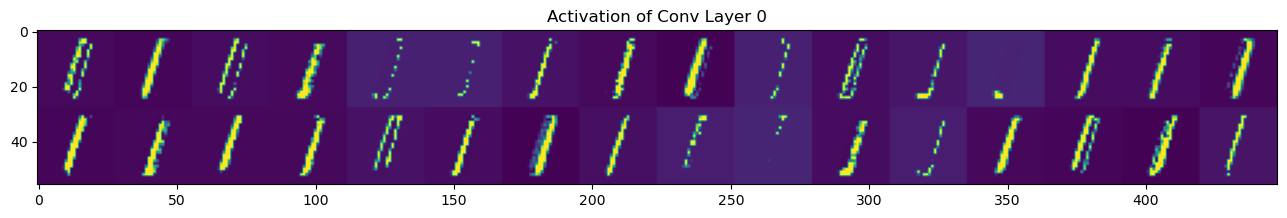

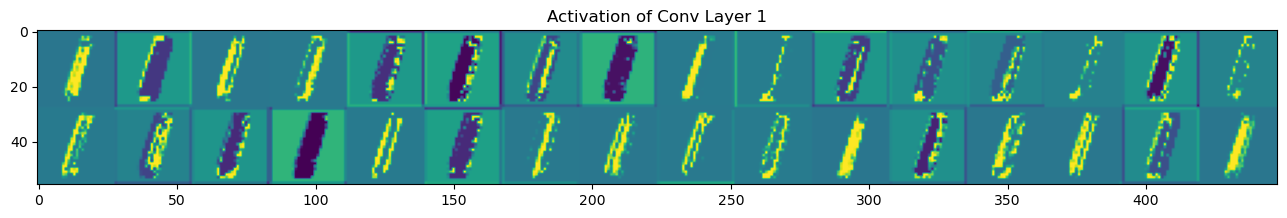

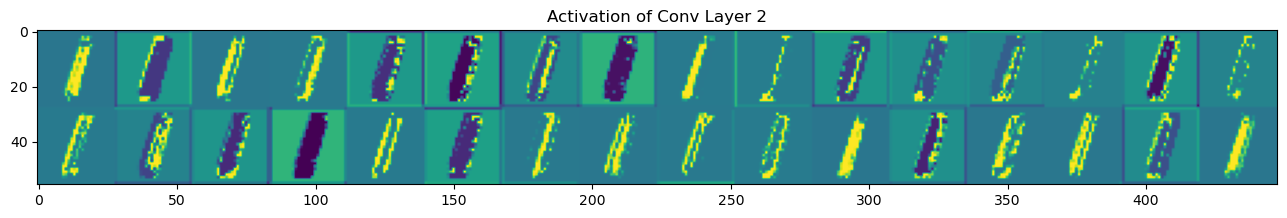

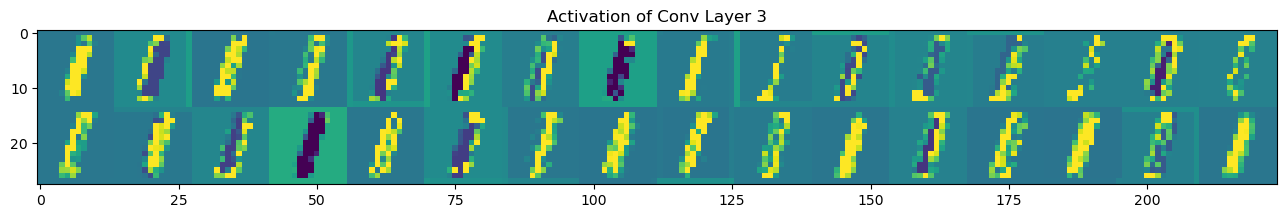

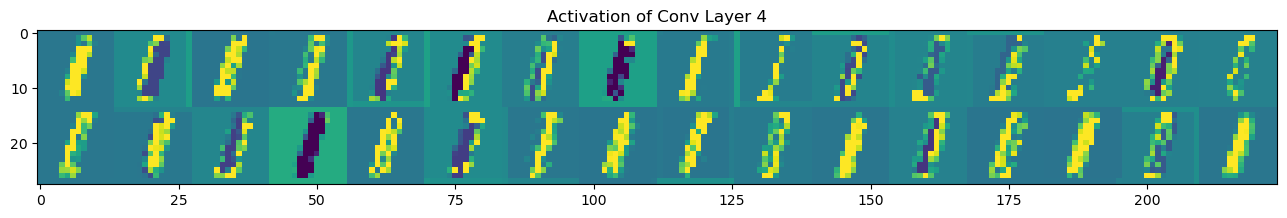

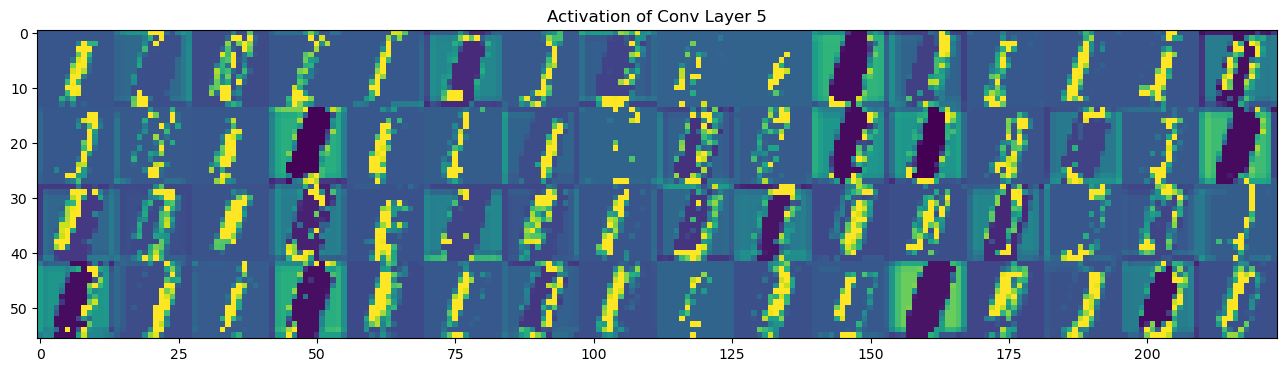

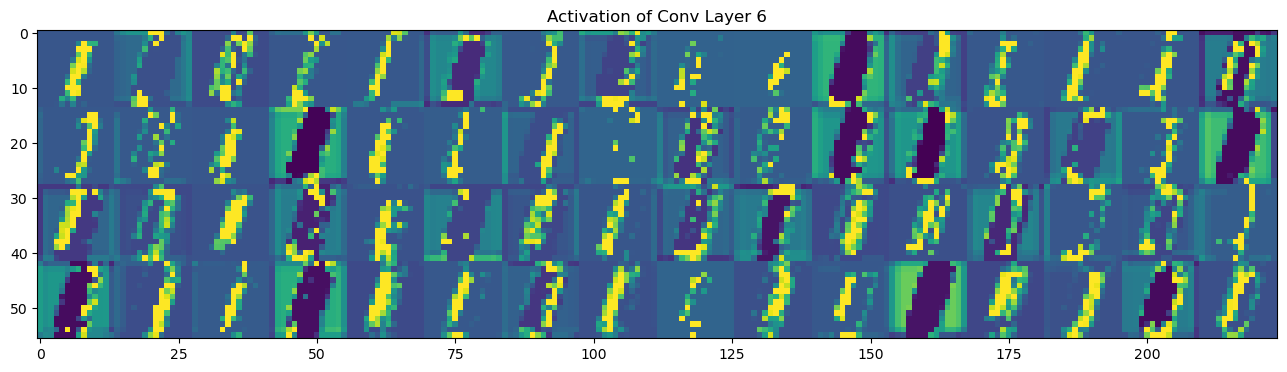

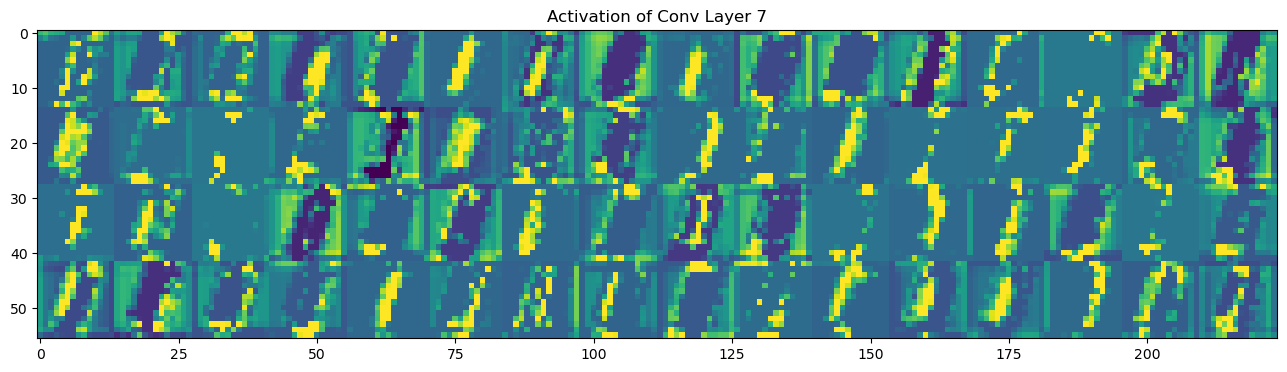

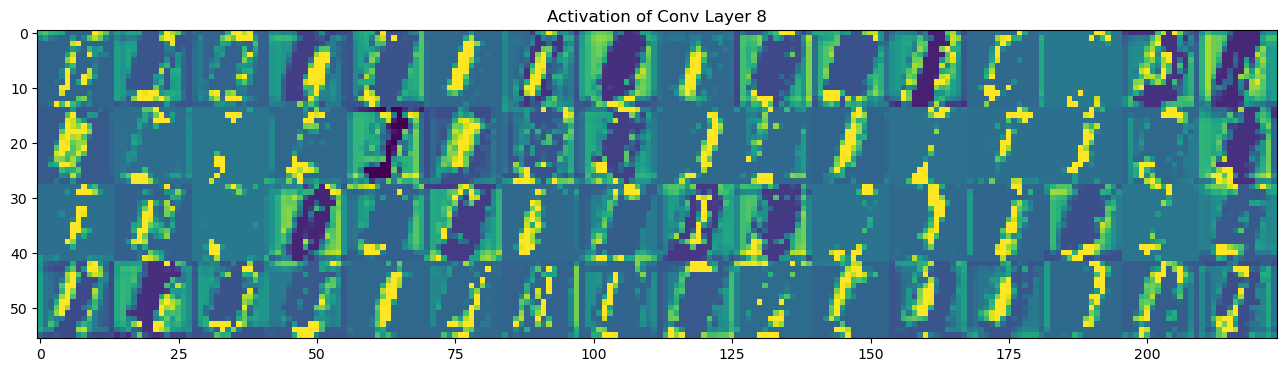

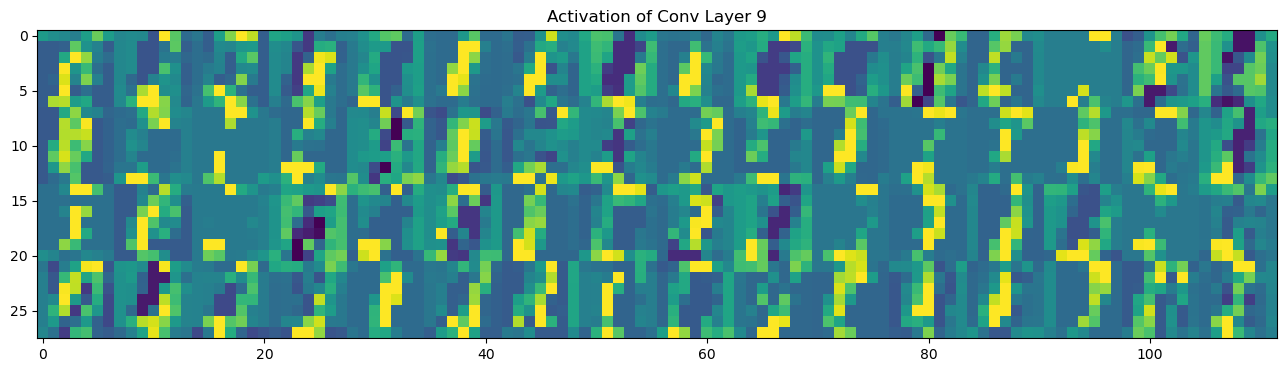

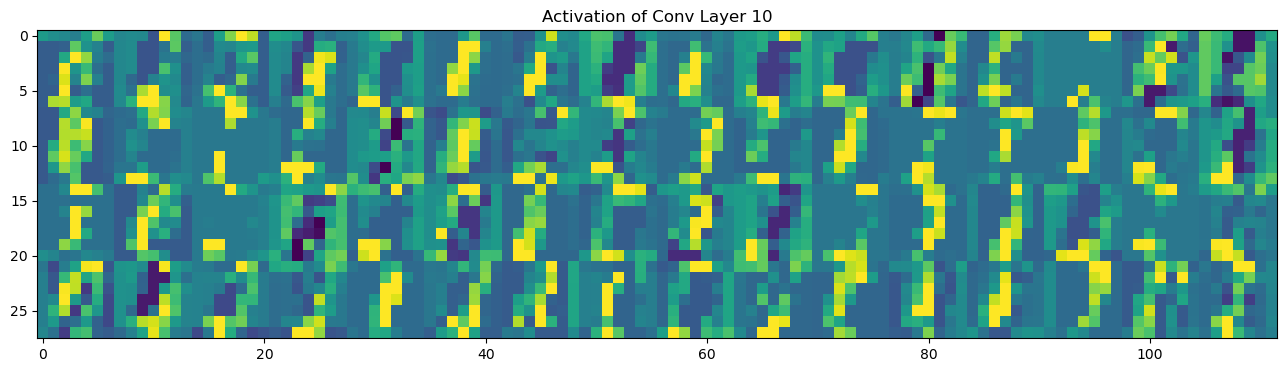

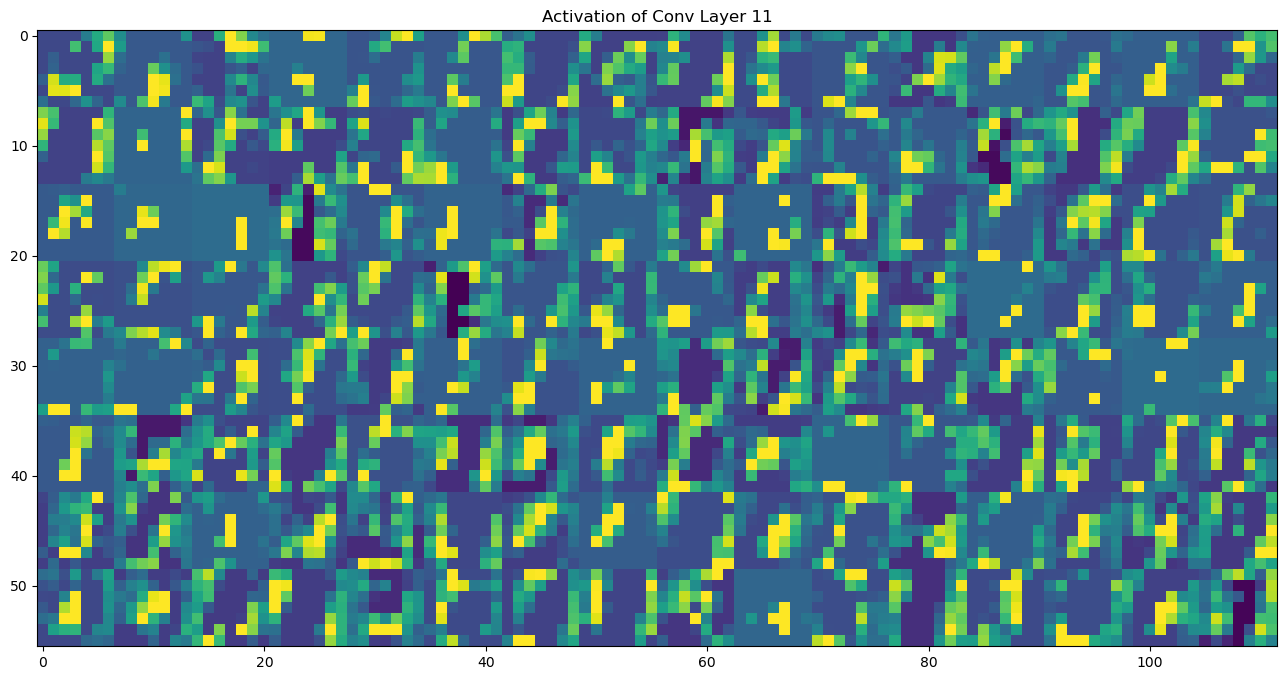

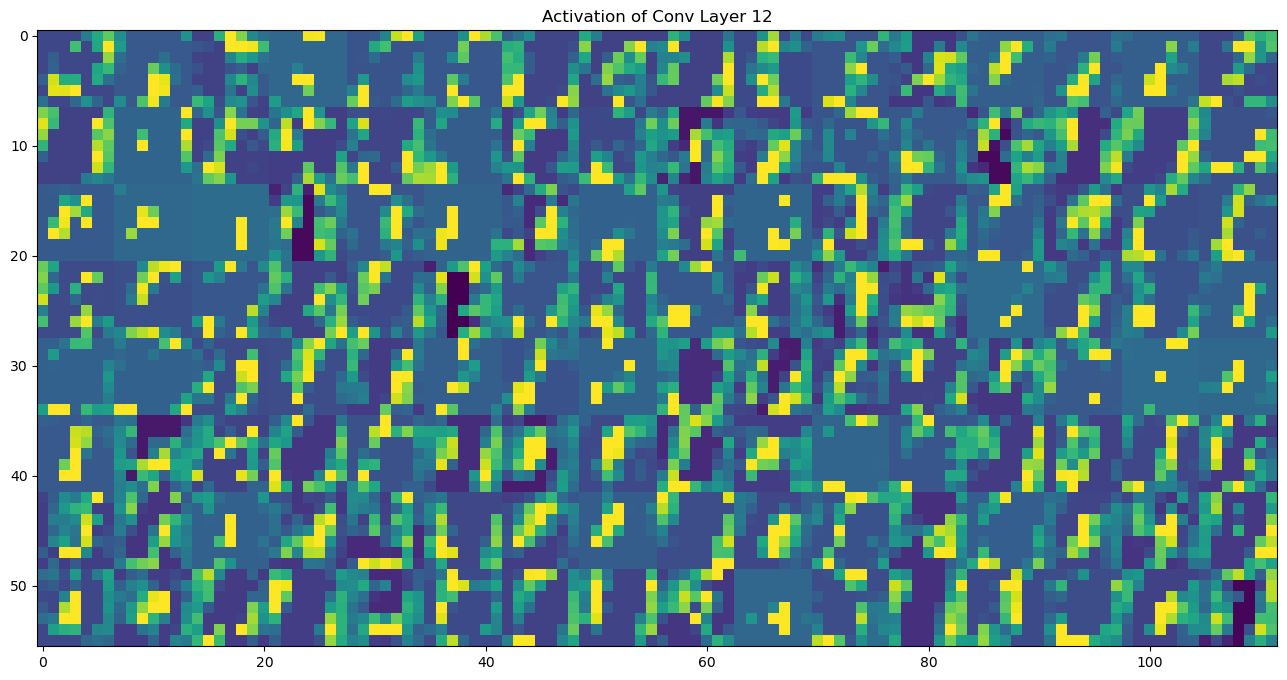

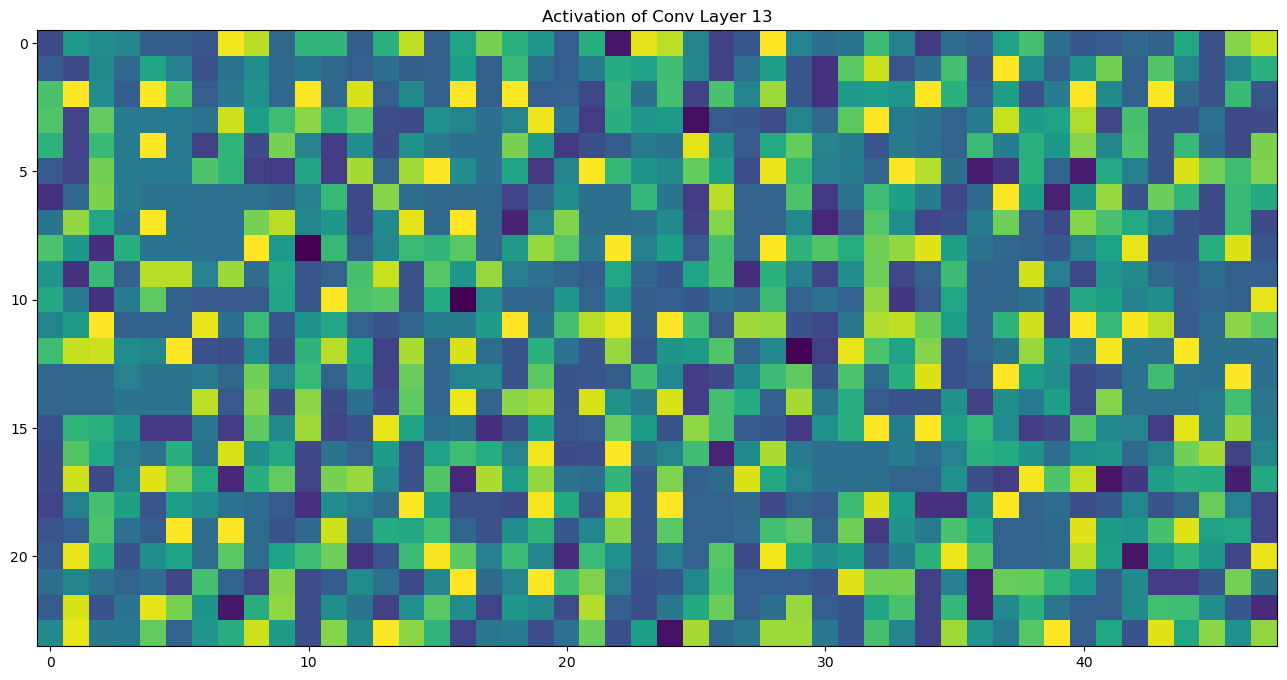

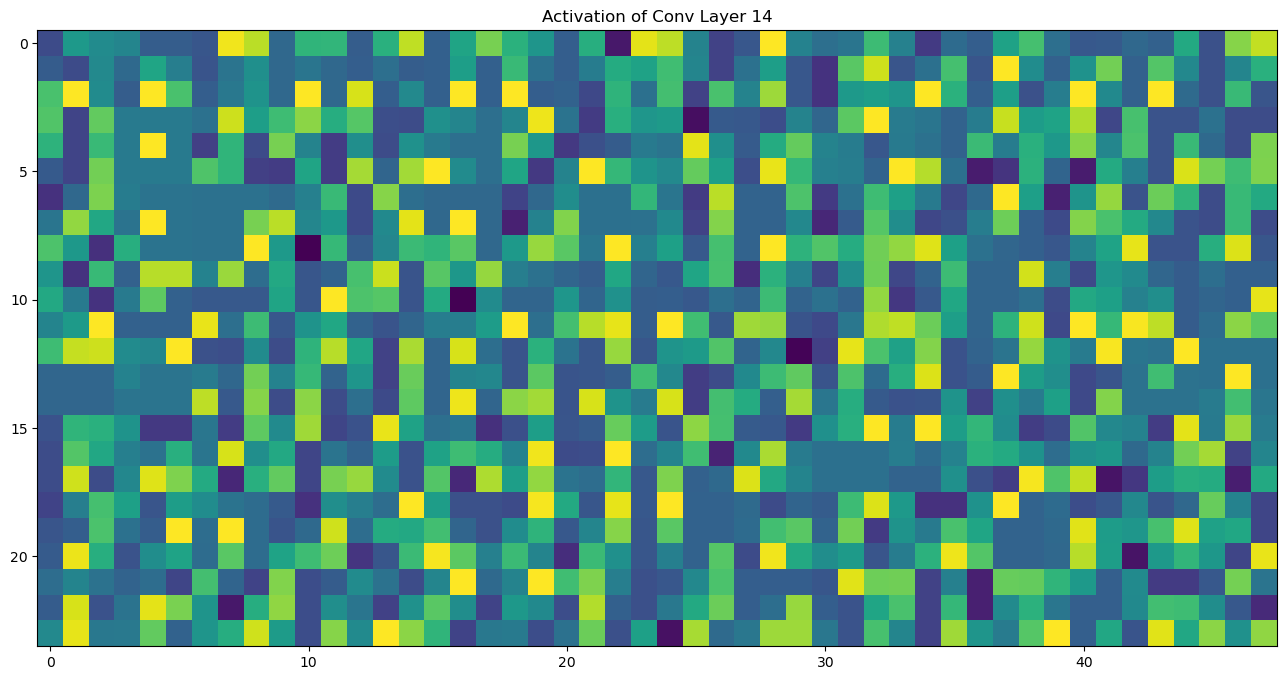

Skipping visualization for layer 15: Shape - (1, 1152)
Skipping visualization for layer 16: Shape - (1, 200)
Skipping visualization for layer 17: Shape - (1, 200)


In [9]:
# Visualize layers for a sample data
visualize_layers(eval_data[2:3])

1/1 [==============================] - 0s 116ms/step


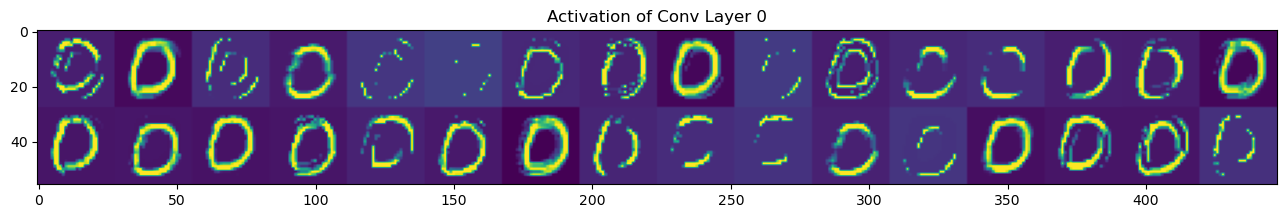

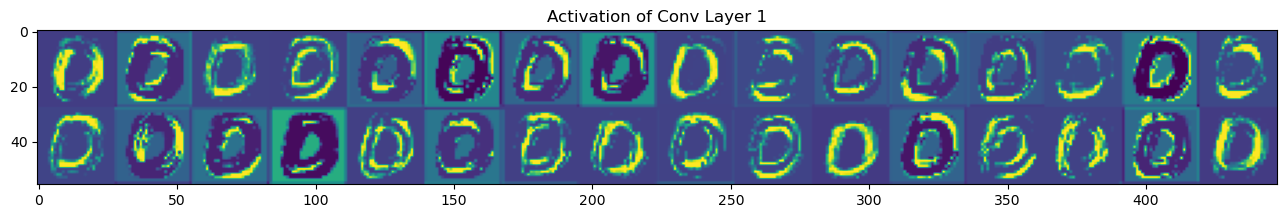

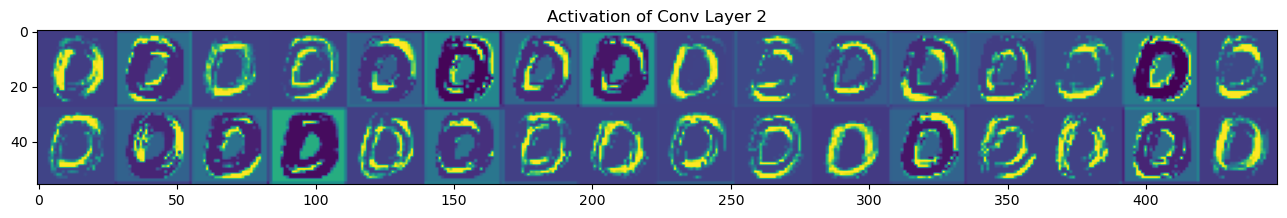

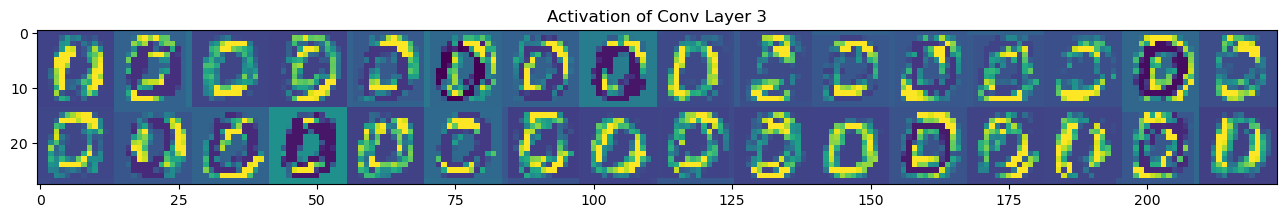

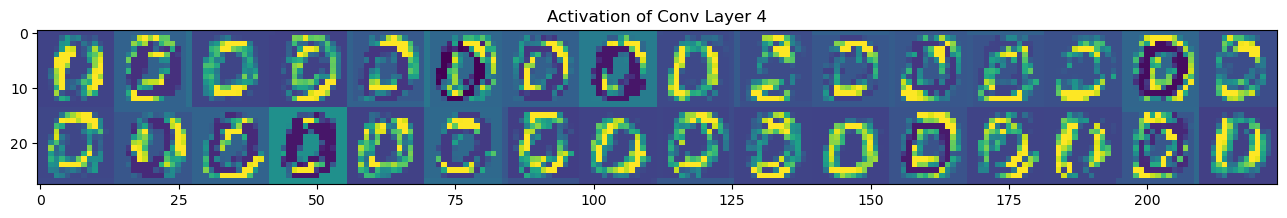

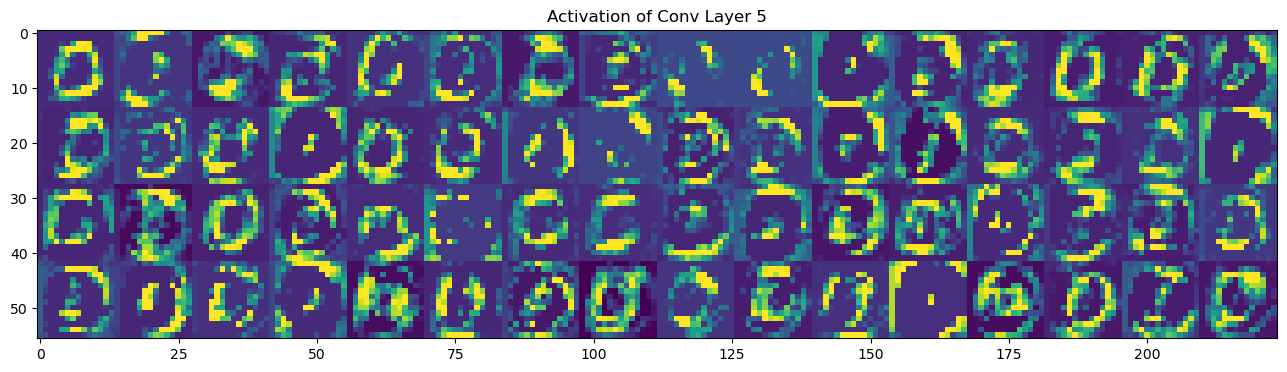

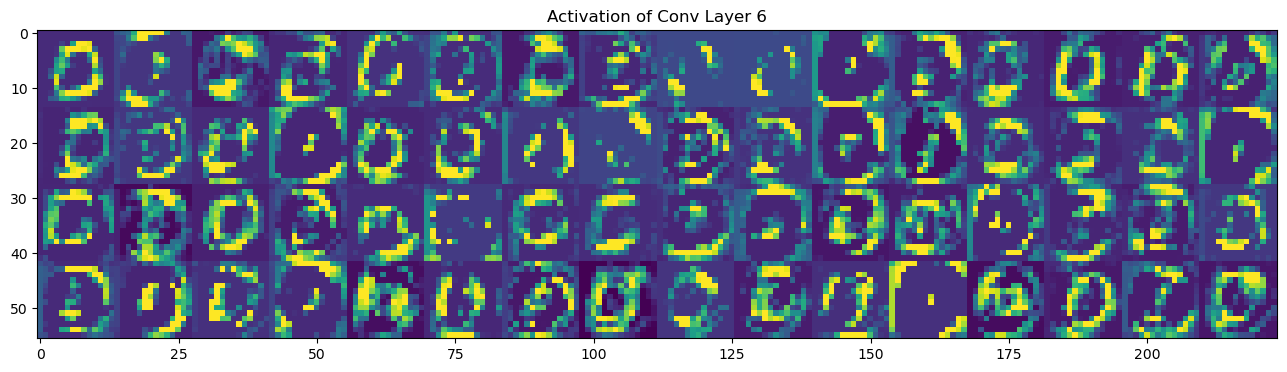

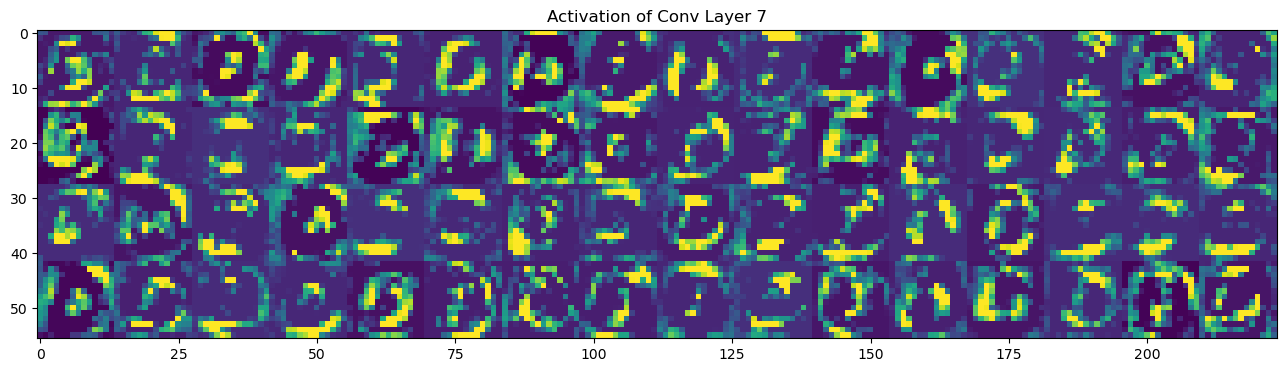

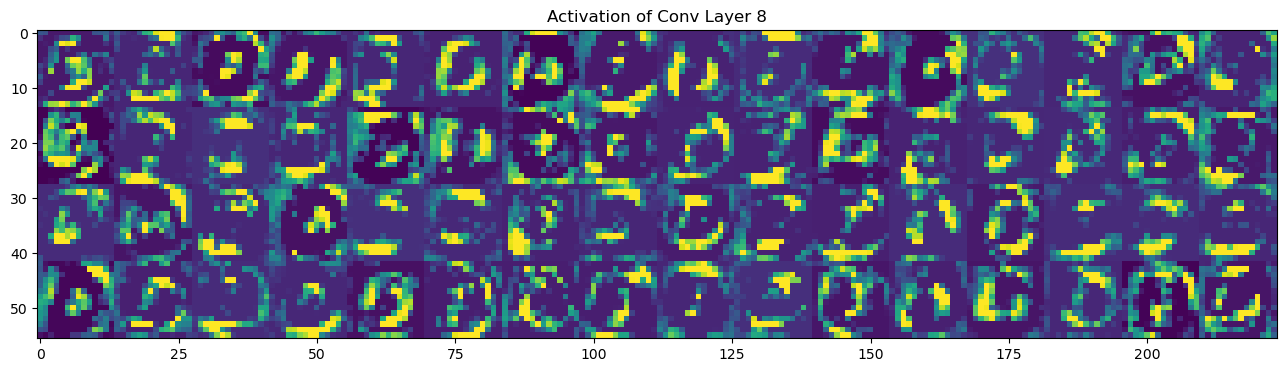

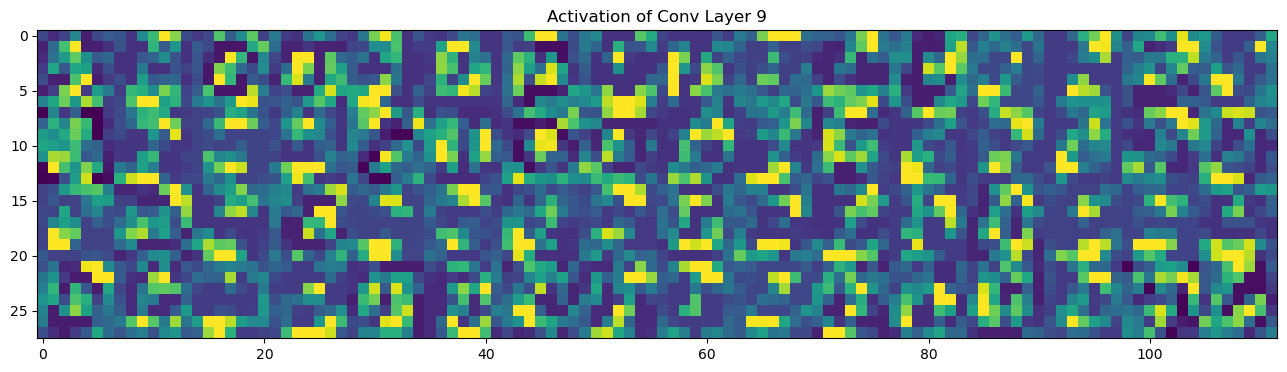

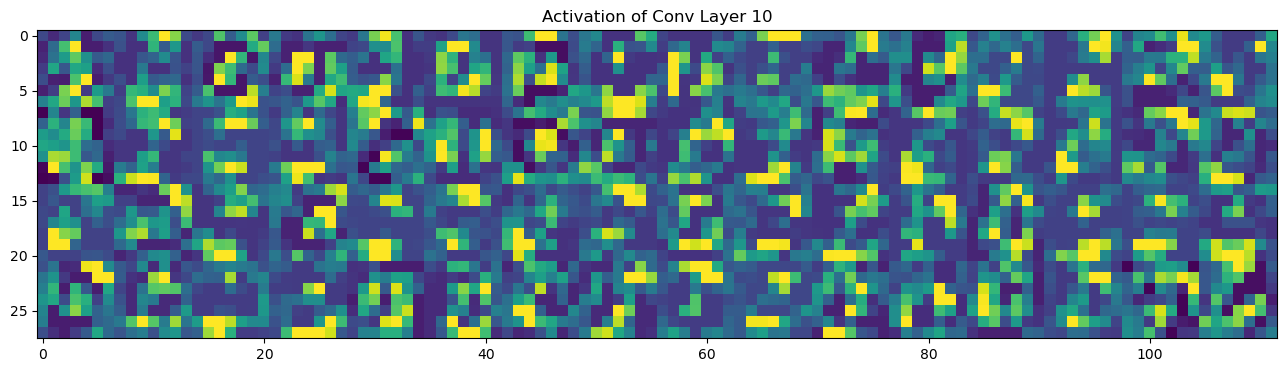

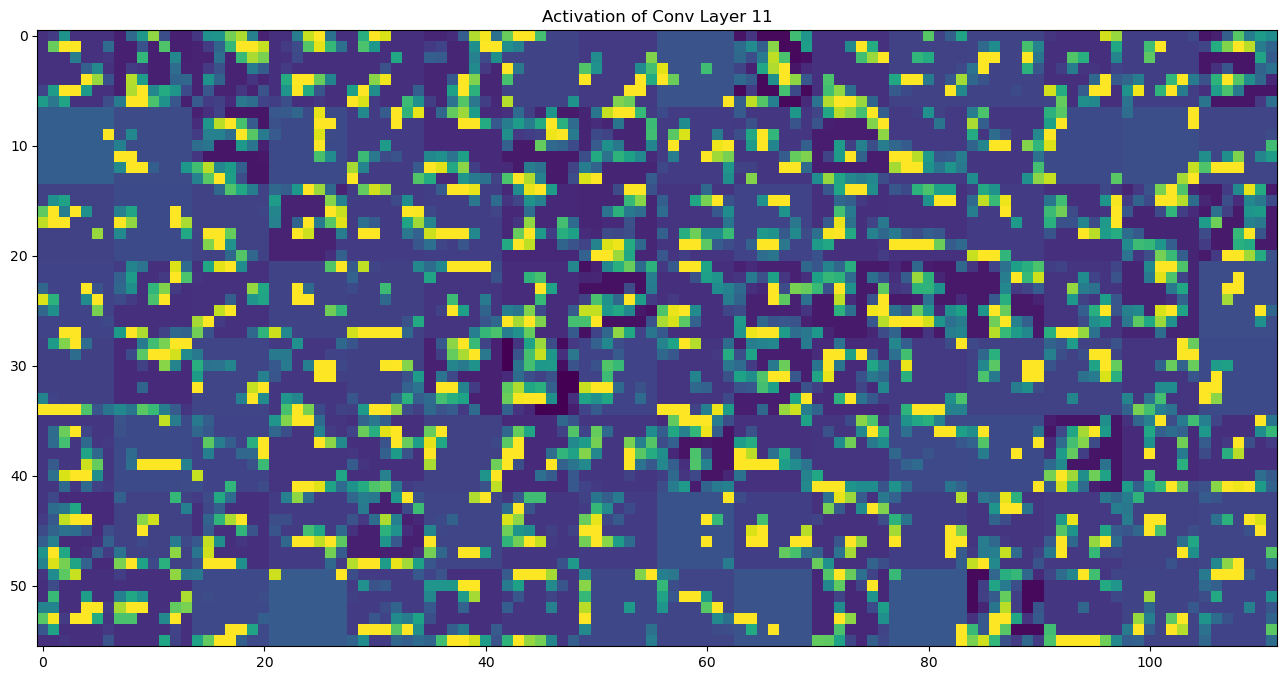

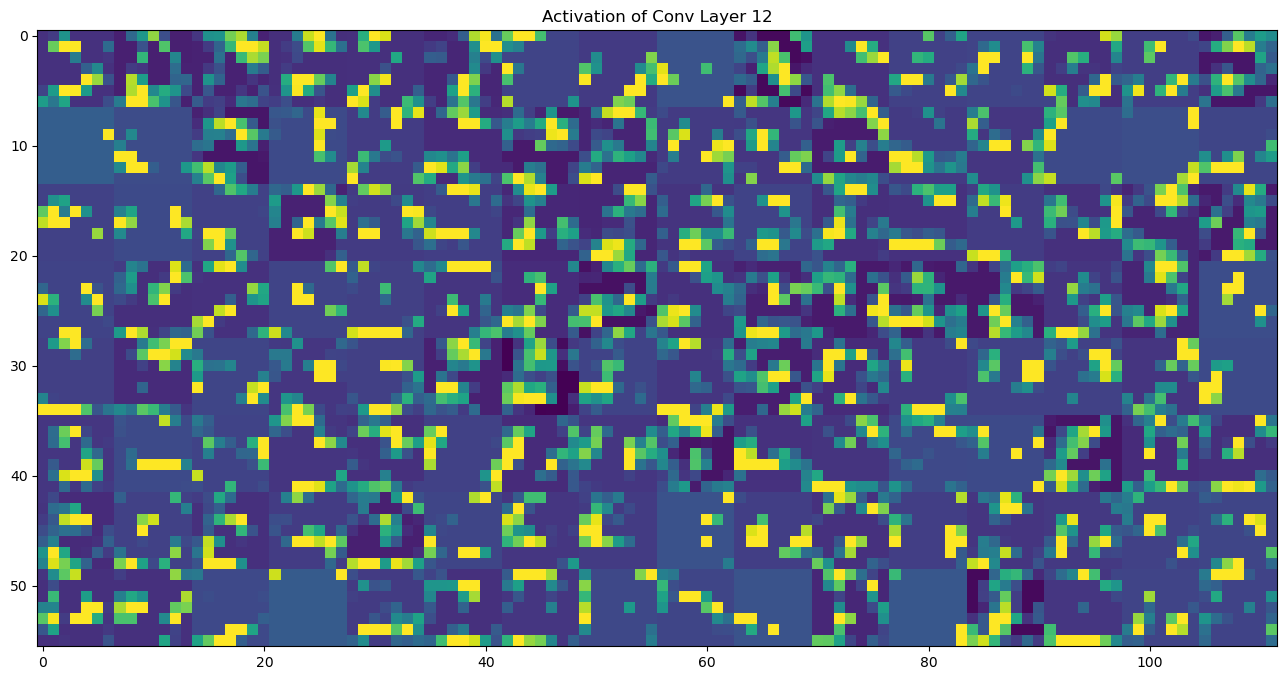

C:\Users\Isaac\anaconda3\envs\Work4\lib\site-packages\ipykernel_launcher.py:16: RuntimeWarning: invalid value encountered in true_divide
  


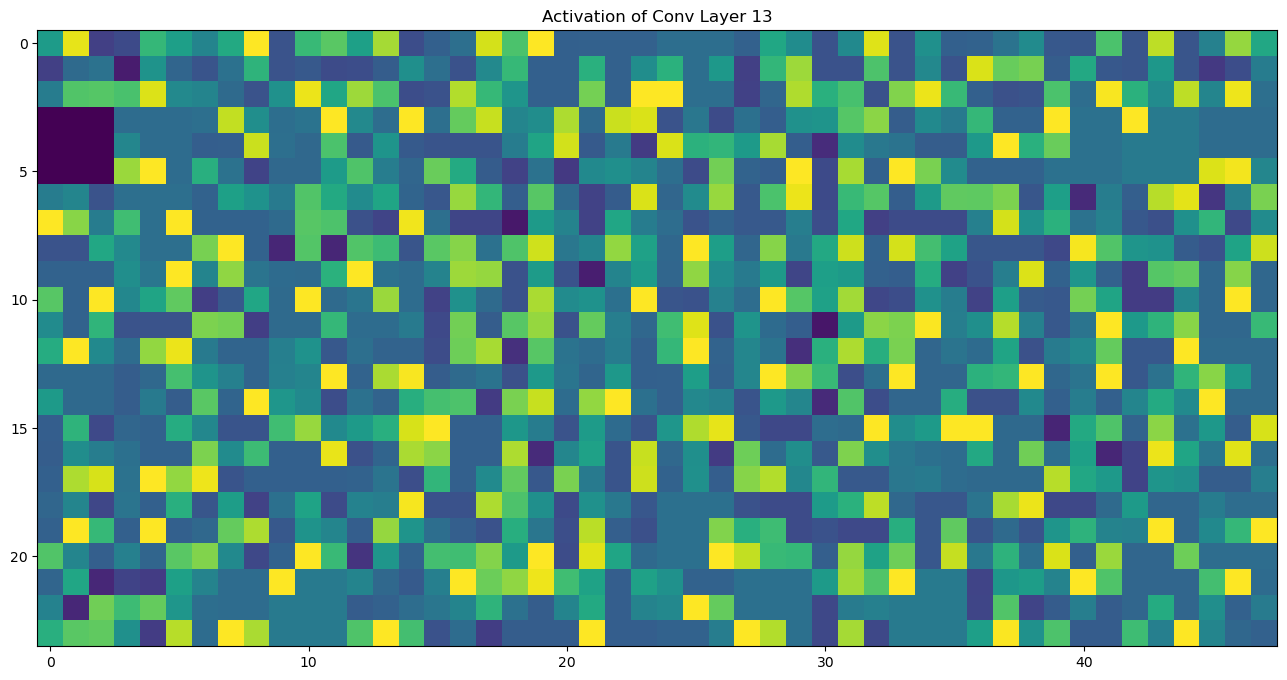

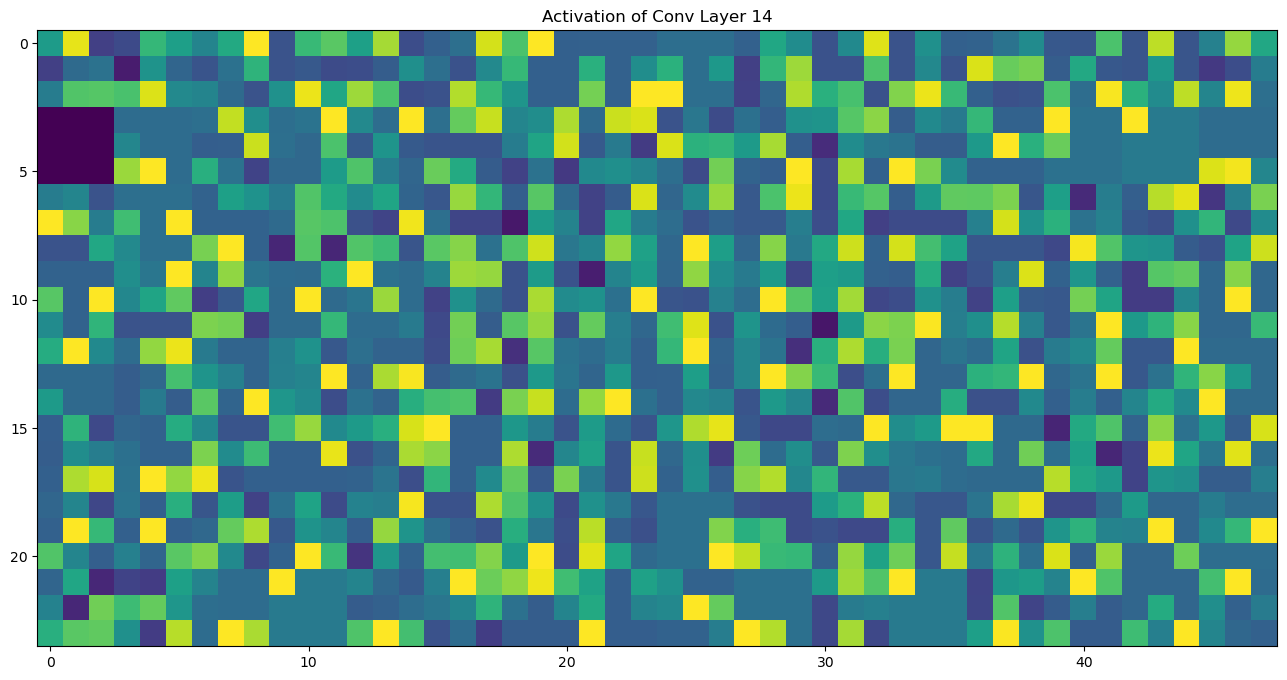

Skipping visualization for layer 15: Shape - (1, 1152)
Skipping visualization for layer 16: Shape - (1, 200)
Skipping visualization for layer 17: Shape - (1, 200)


In [10]:
visualize_layers(eval_data[10:11])

1/1 [==============================] - 0s 127ms/step


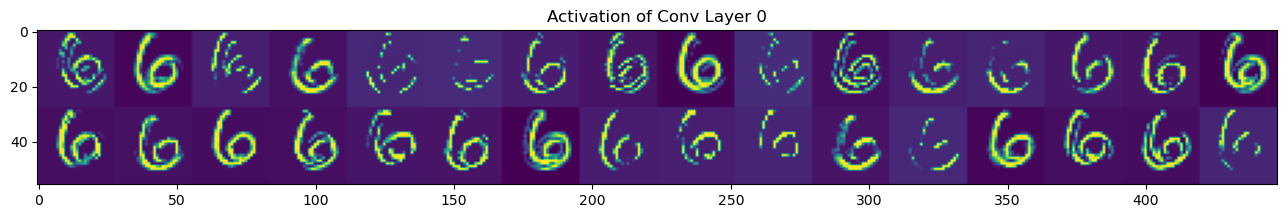

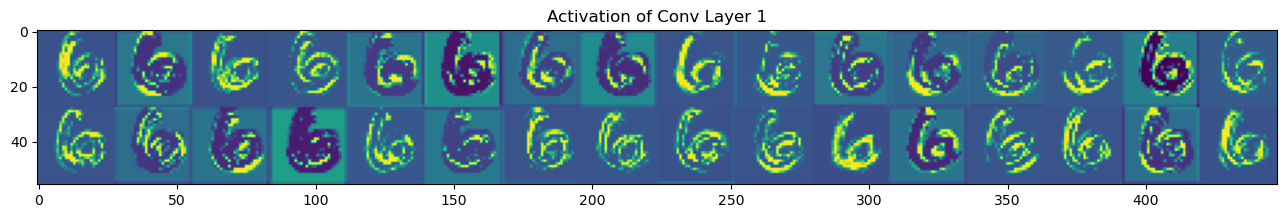

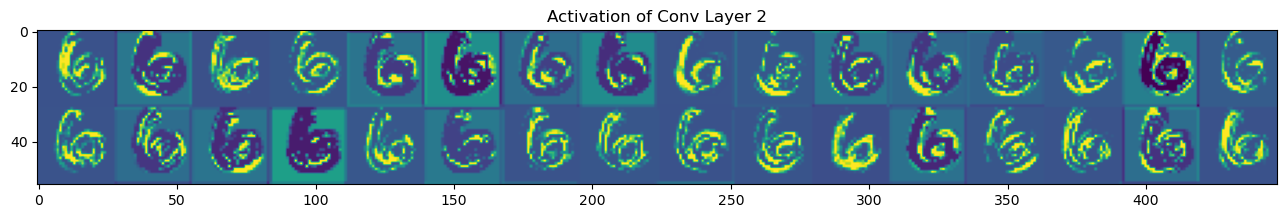

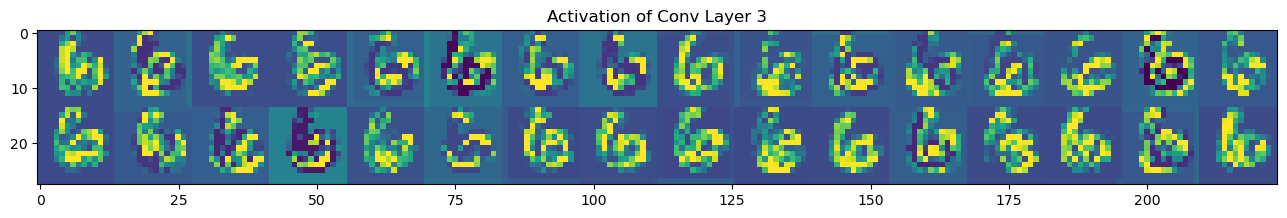

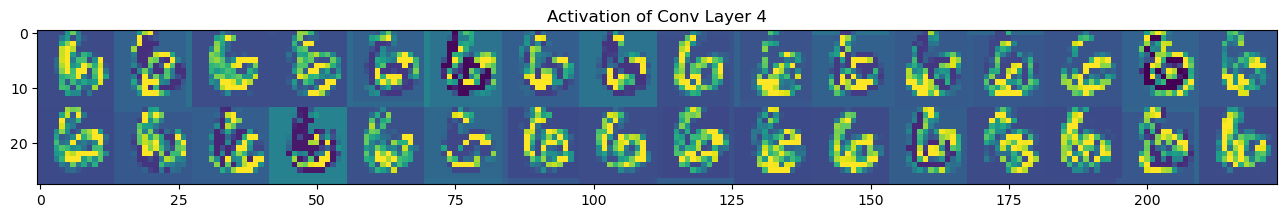

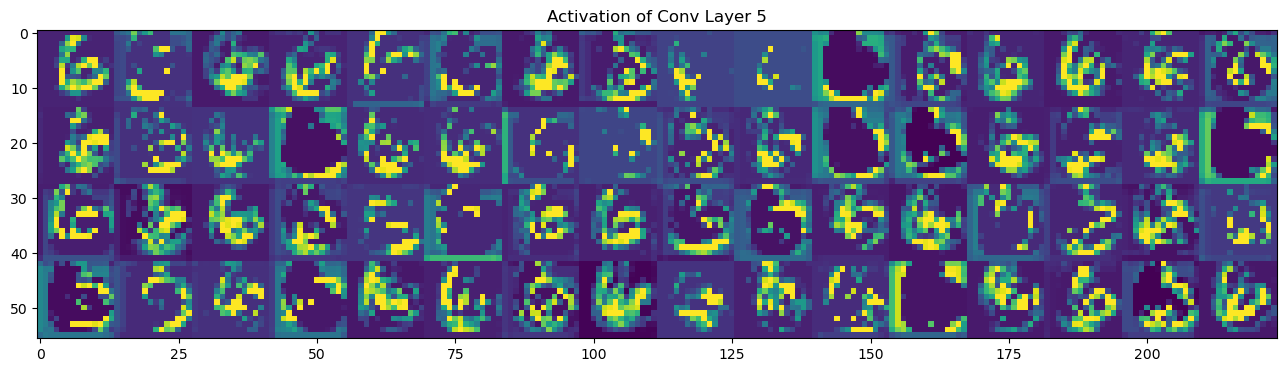

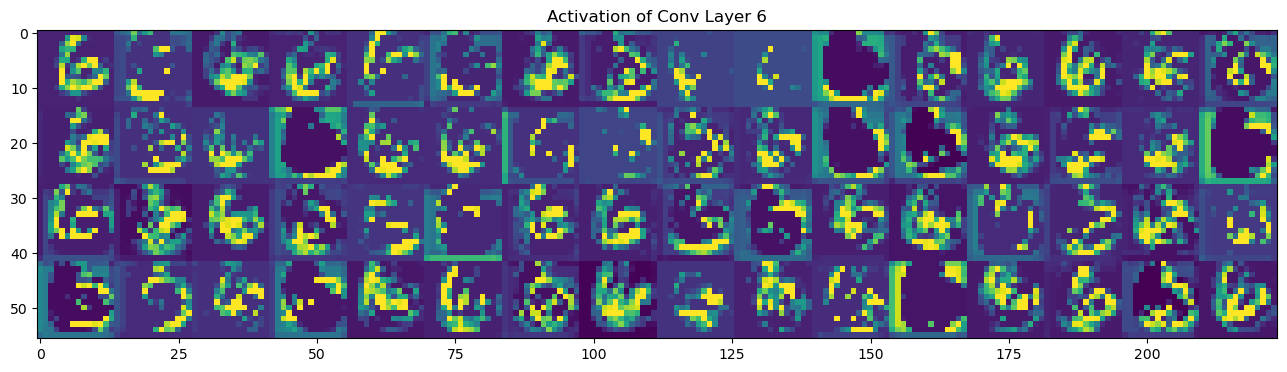

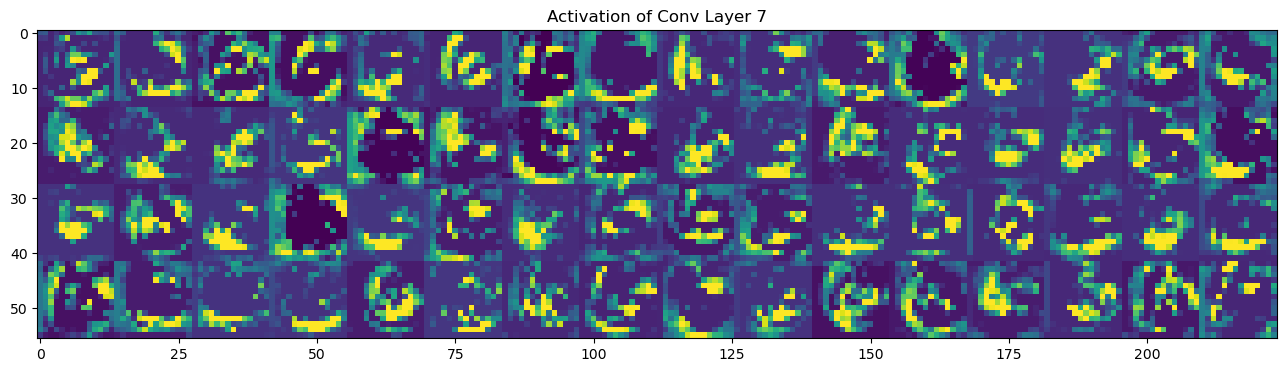

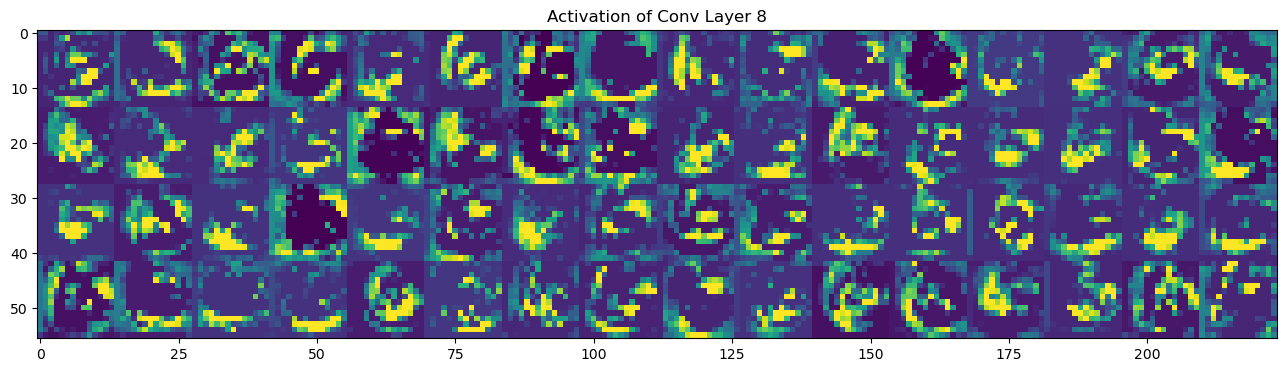

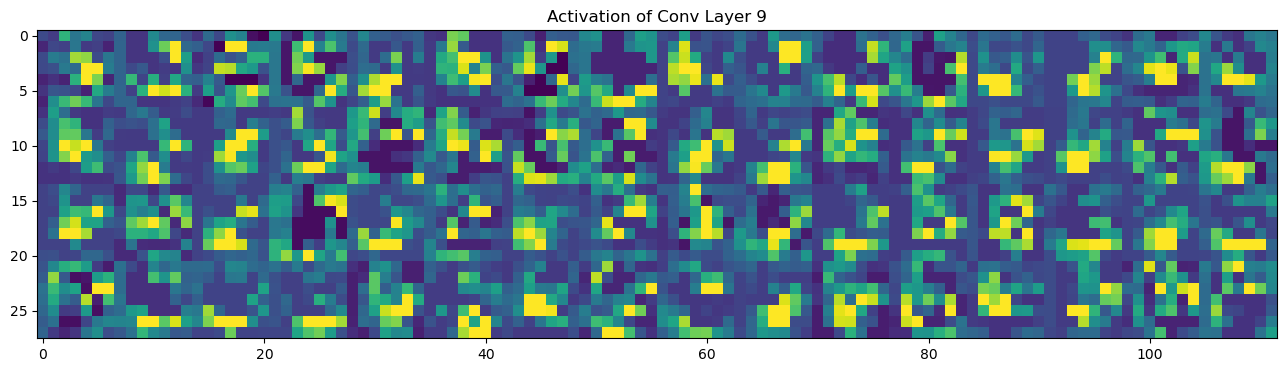

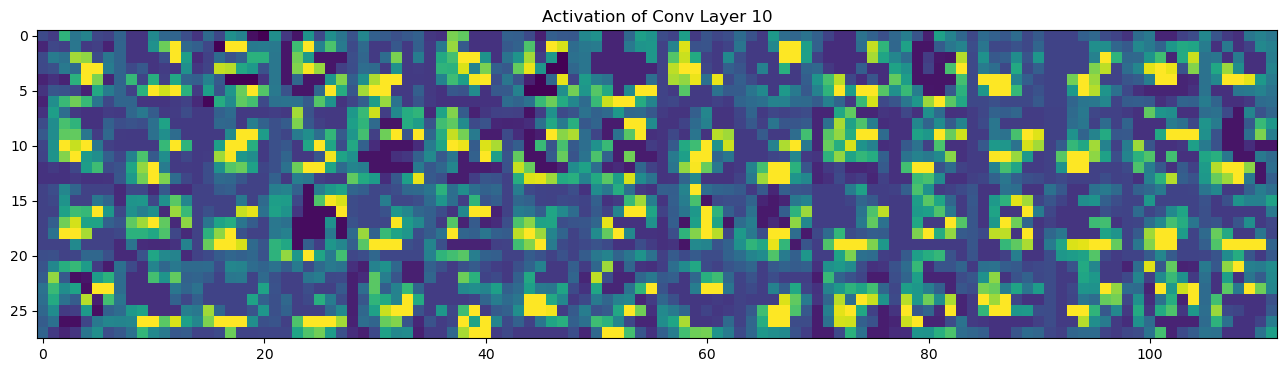

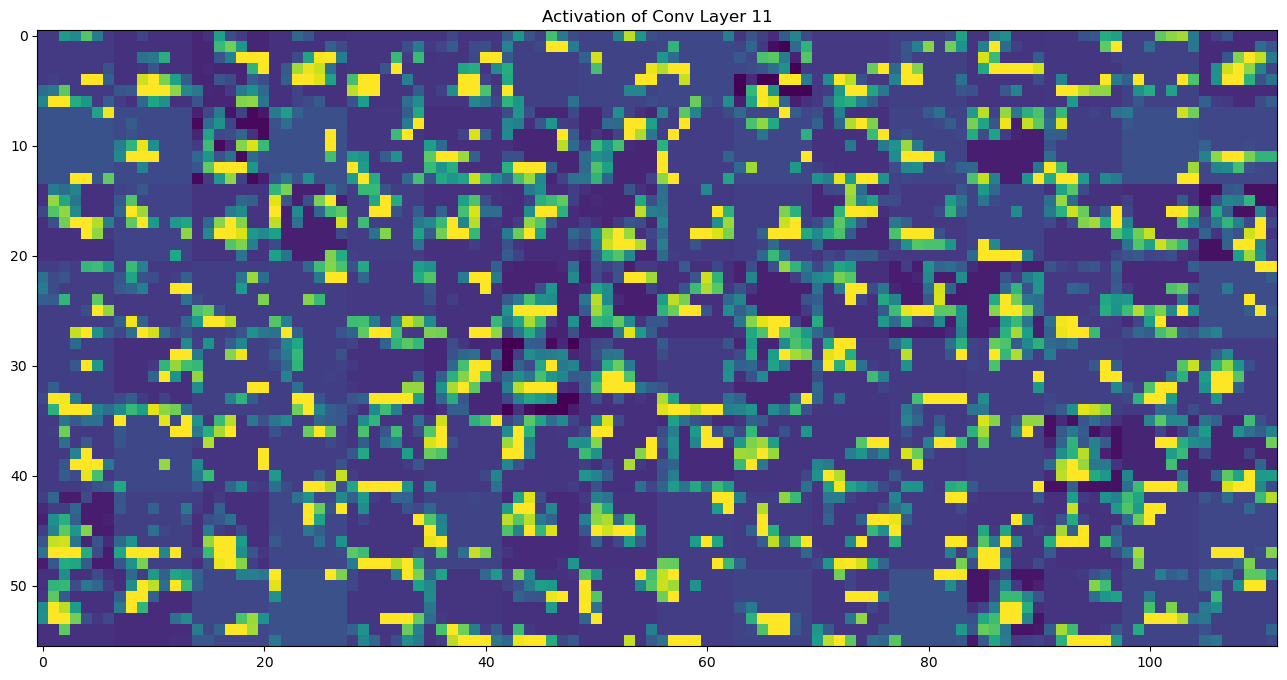

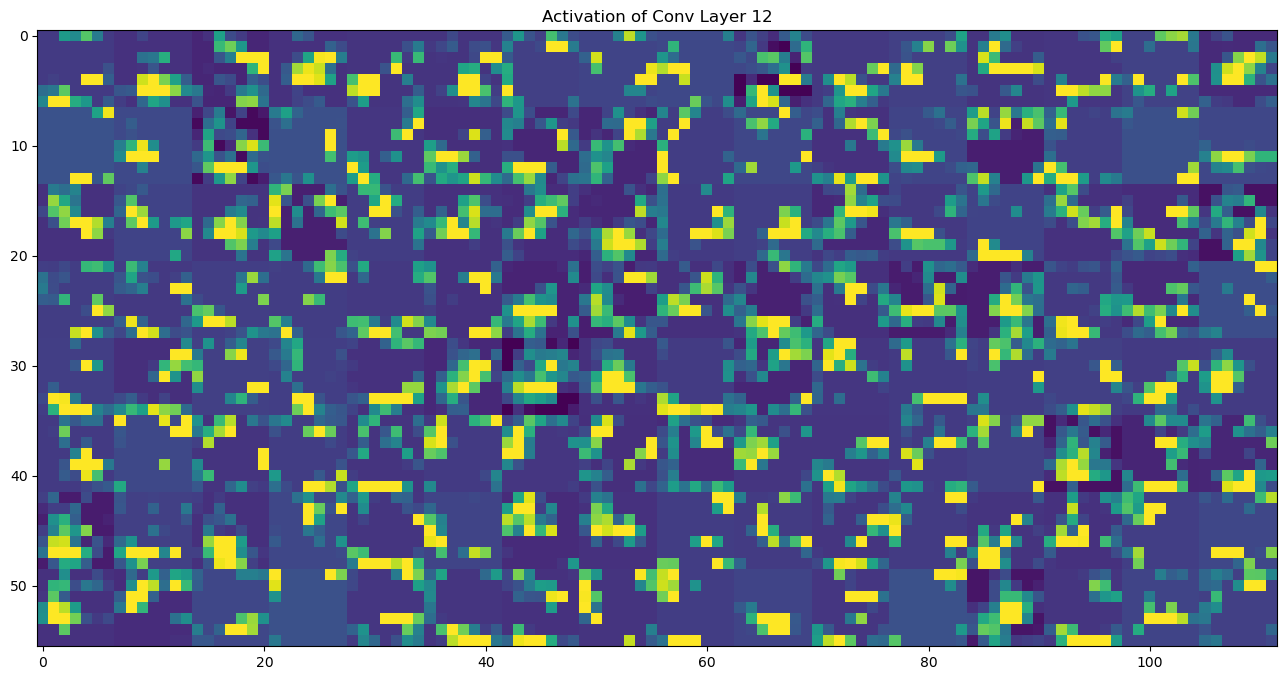

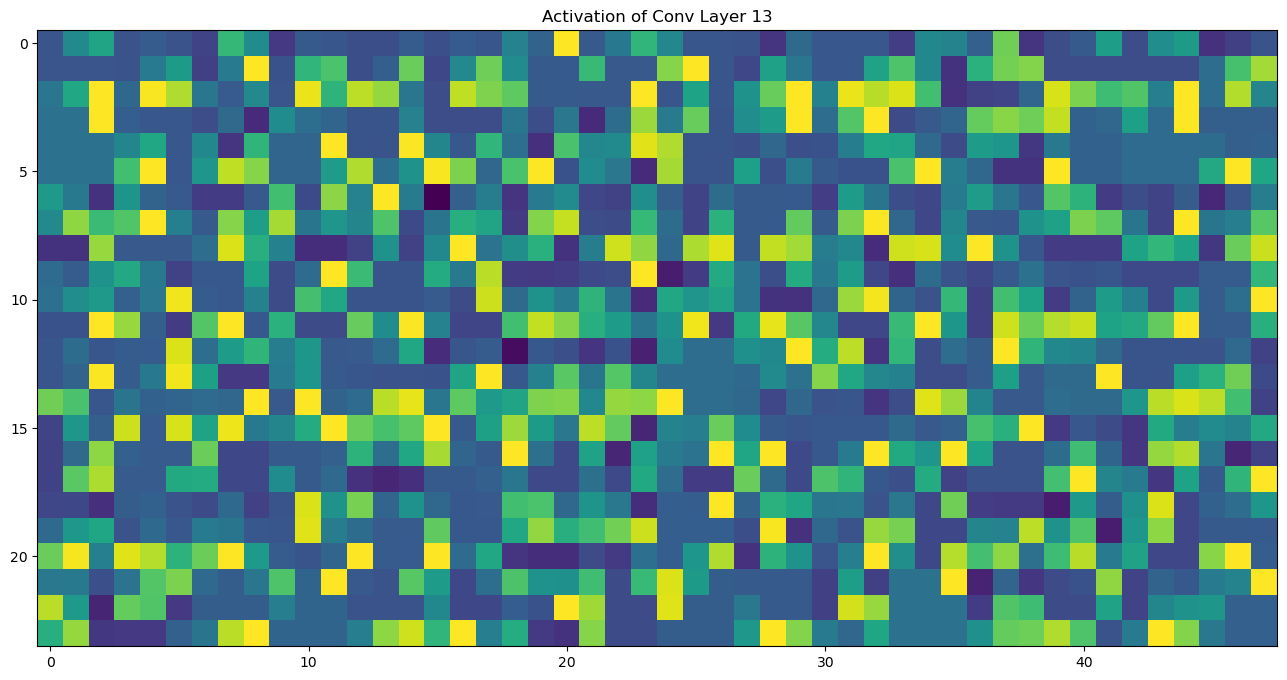

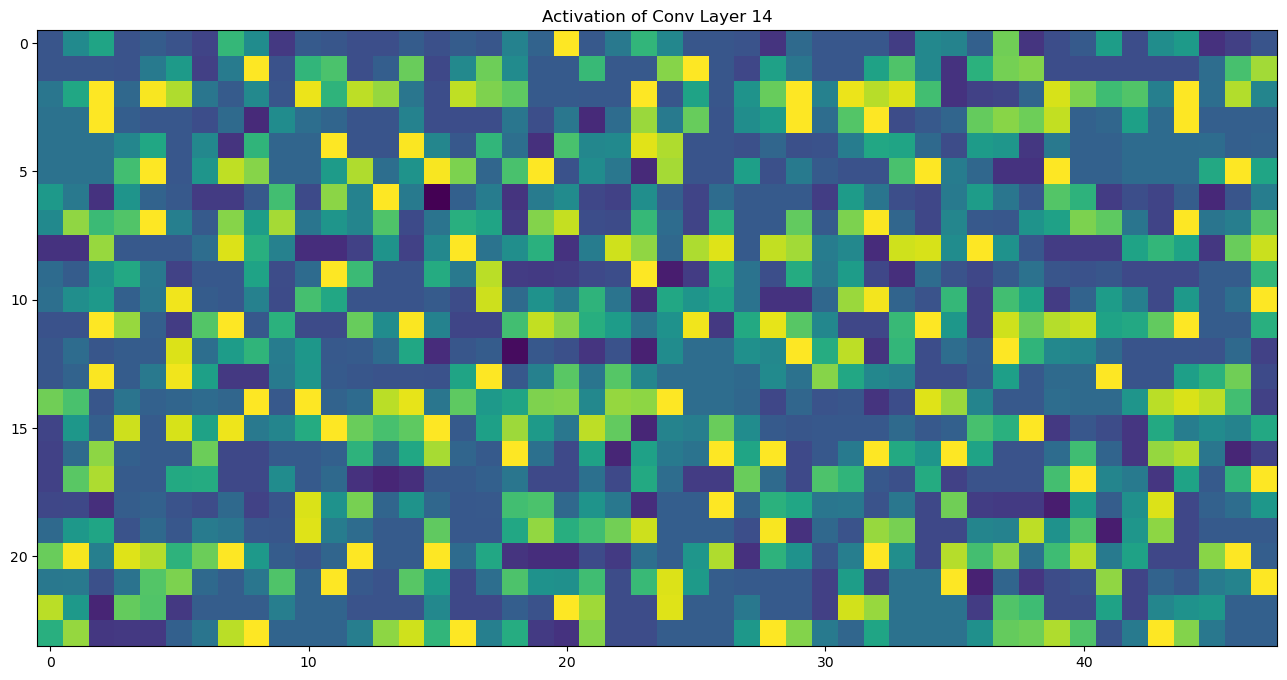

Skipping visualization for layer 15: Shape - (11, 1152)
Skipping visualization for layer 16: Shape - (11, 200)
Skipping visualization for layer 17: Shape - (11, 200)


In [11]:
visualize_layers(eval_data[100:111])

1/1 [==============================] - 0s 127ms/step


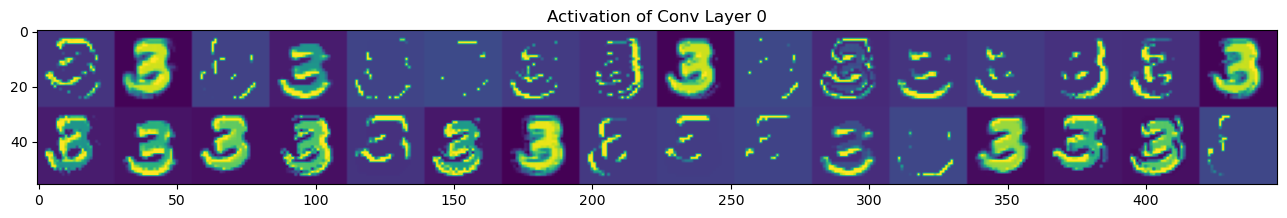

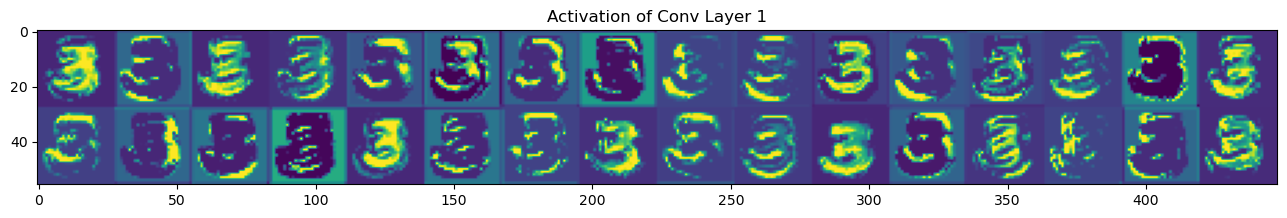

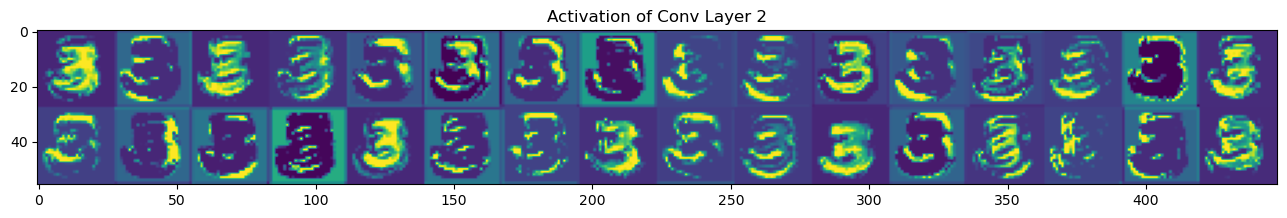

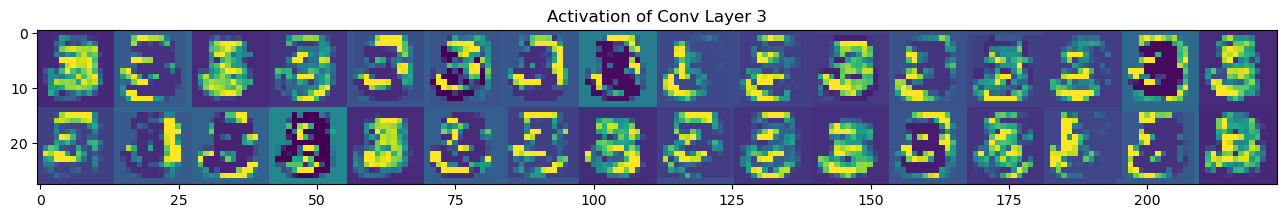

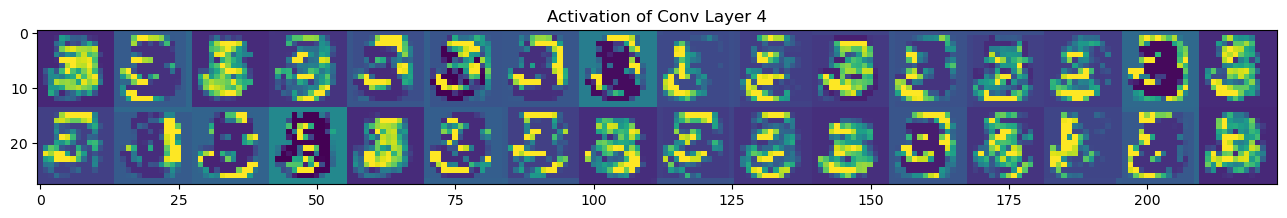

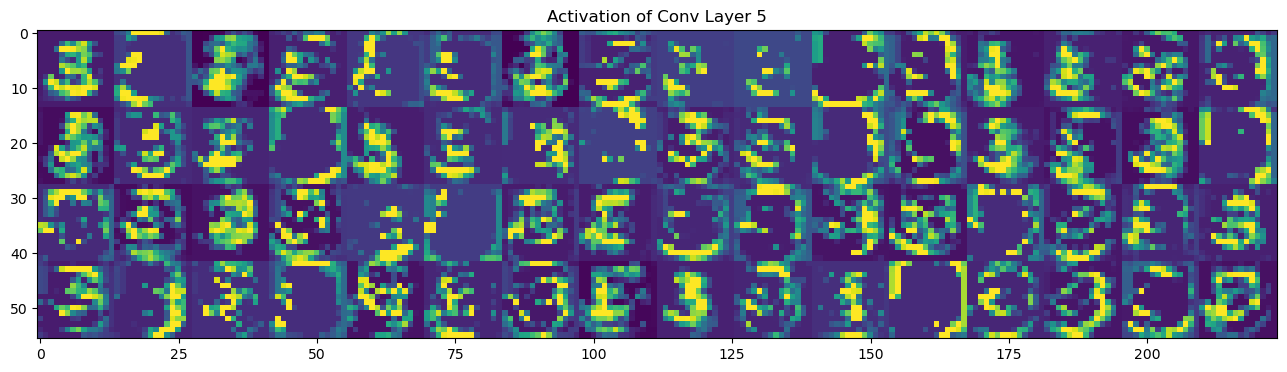

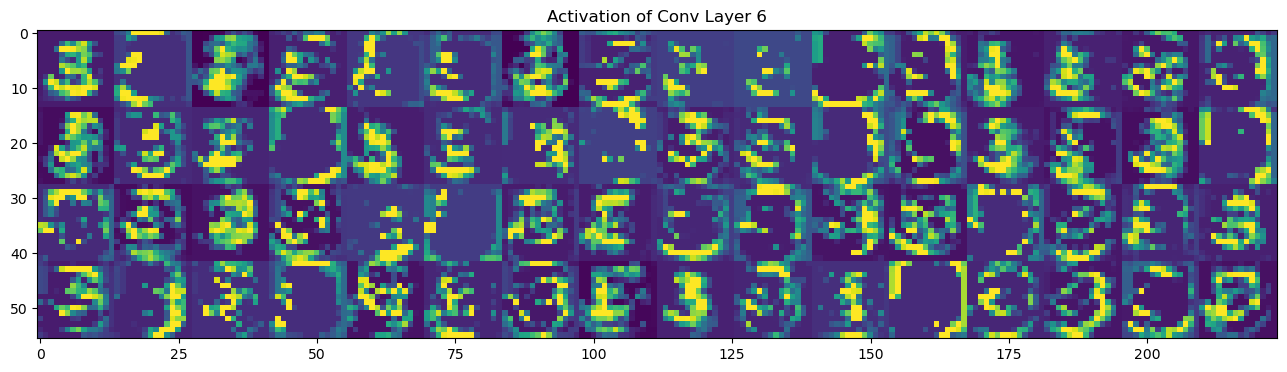

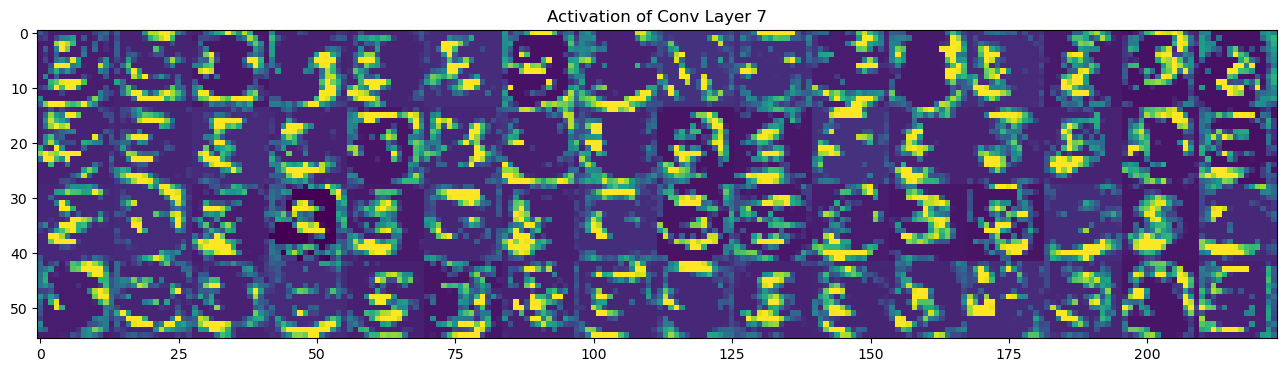

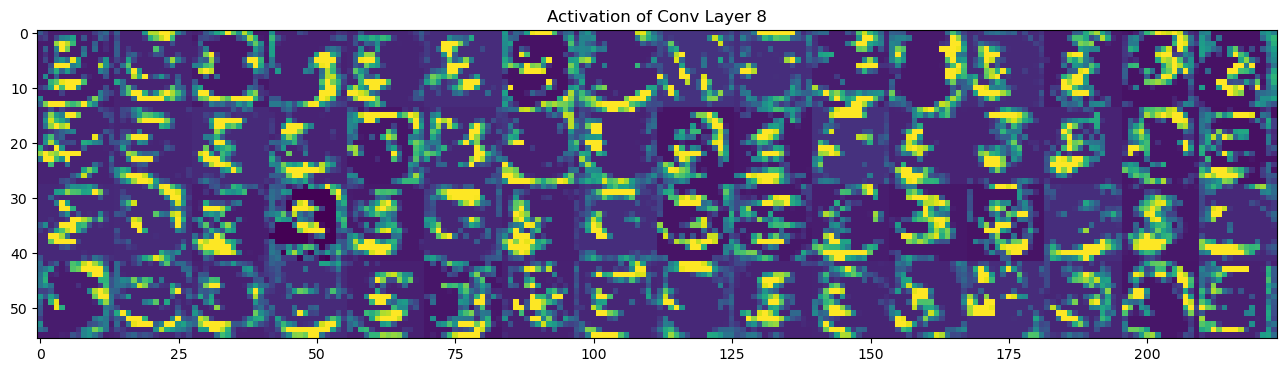

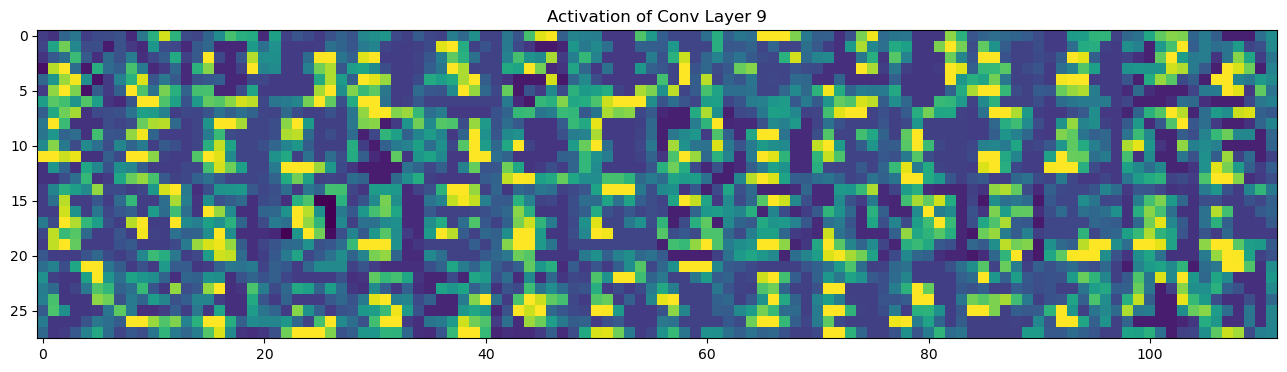

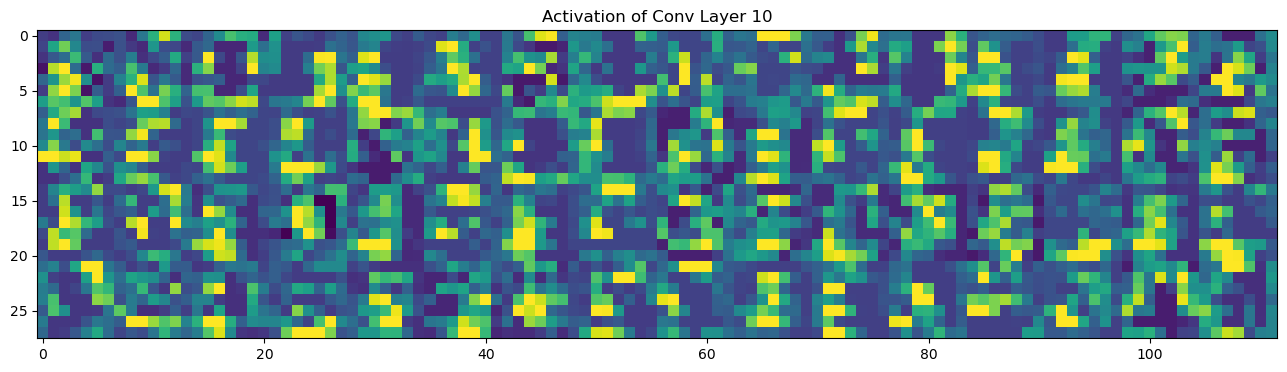

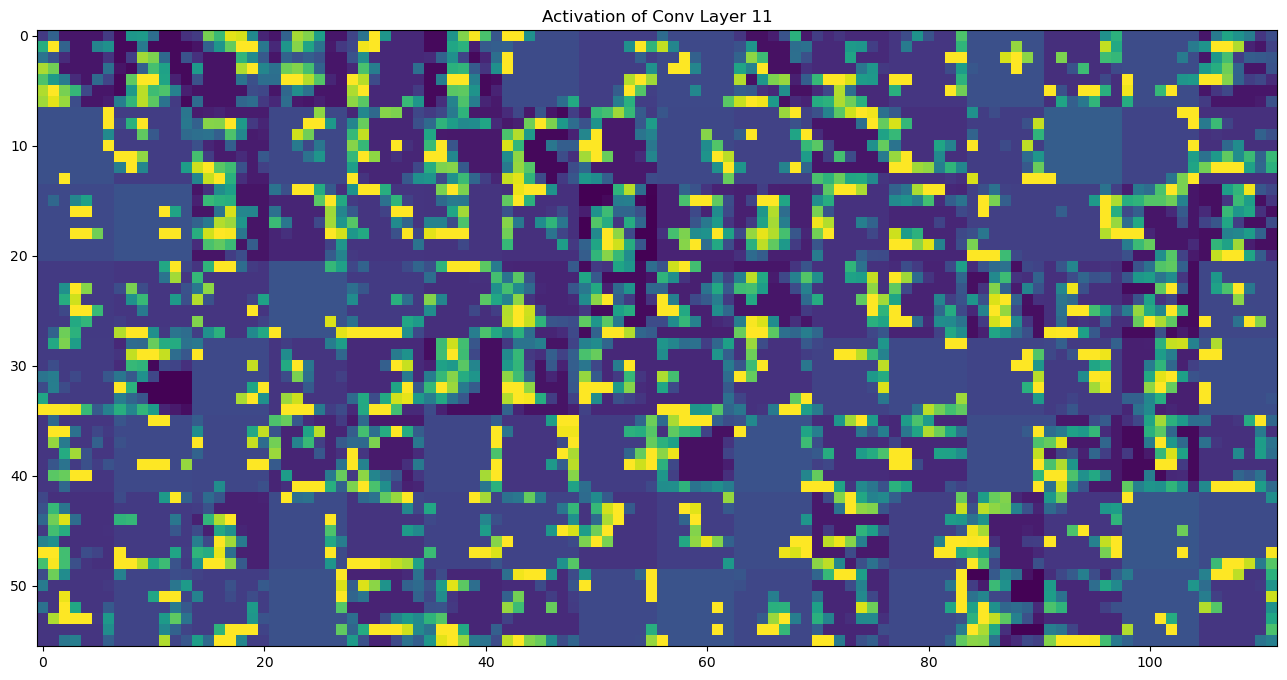

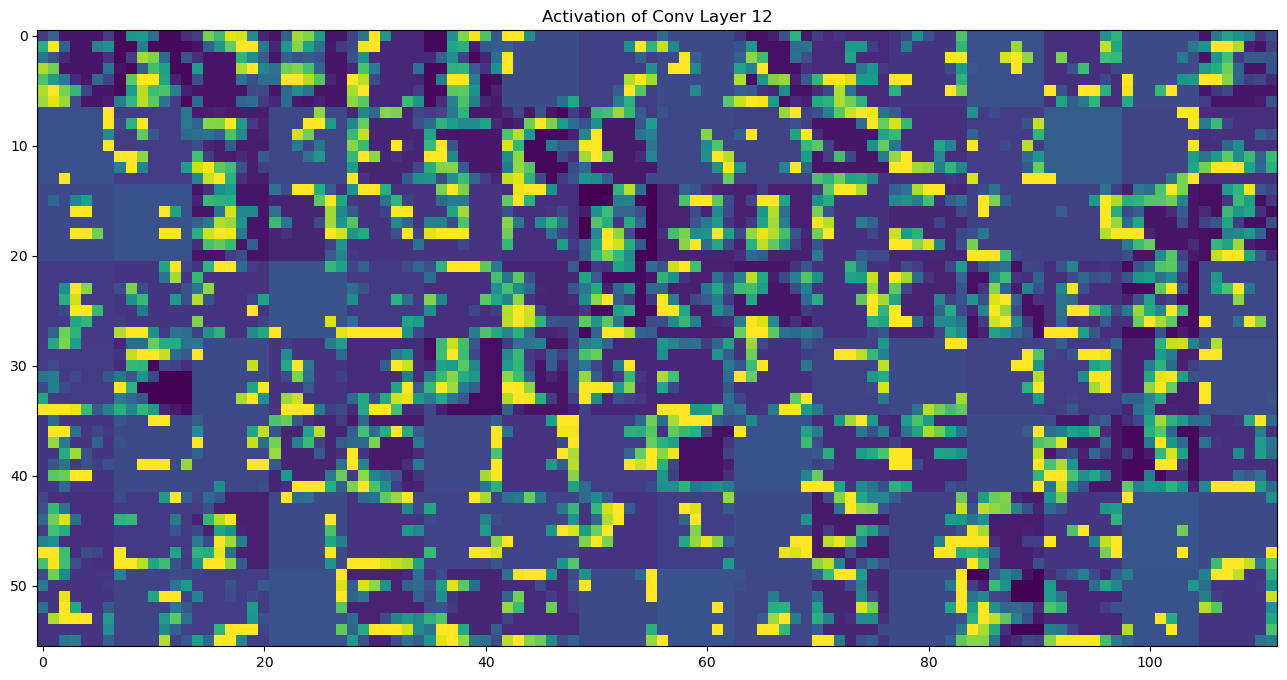

C:\Users\Isaac\anaconda3\envs\Work4\lib\site-packages\ipykernel_launcher.py:16: RuntimeWarning: invalid value encountered in true_divide
  


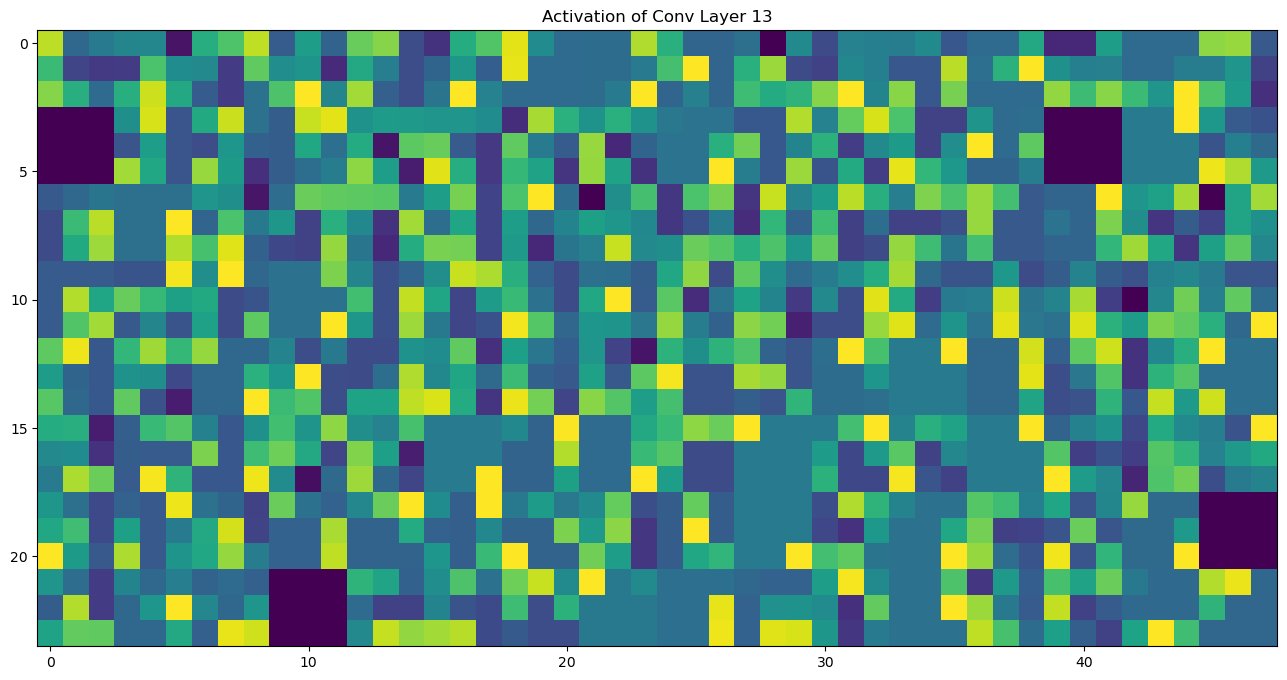

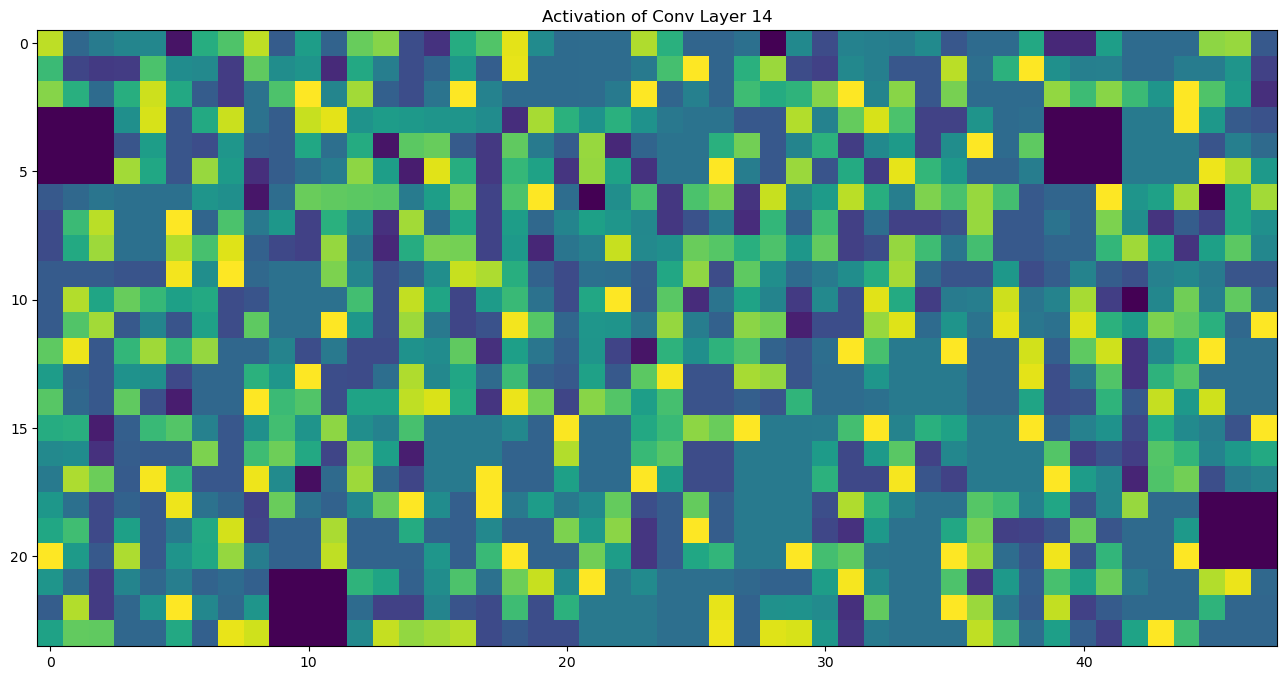

Skipping visualization for layer 15: Shape - (21, 1152)
Skipping visualization for layer 16: Shape - (21, 200)
Skipping visualization for layer 17: Shape - (21, 200)


In [12]:
visualize_layers(eval_data[200:221])

1/1 [==============================] - 0s 128ms/step


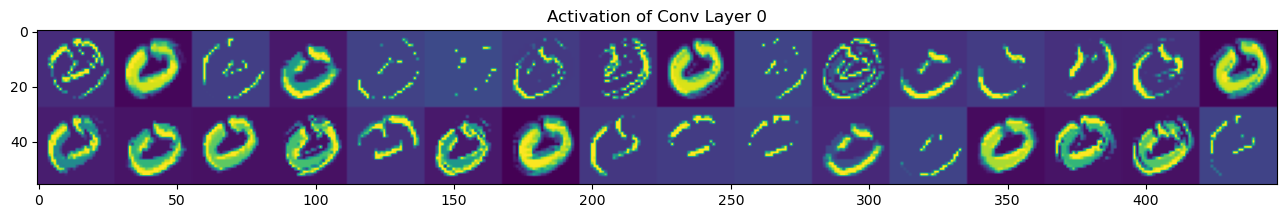

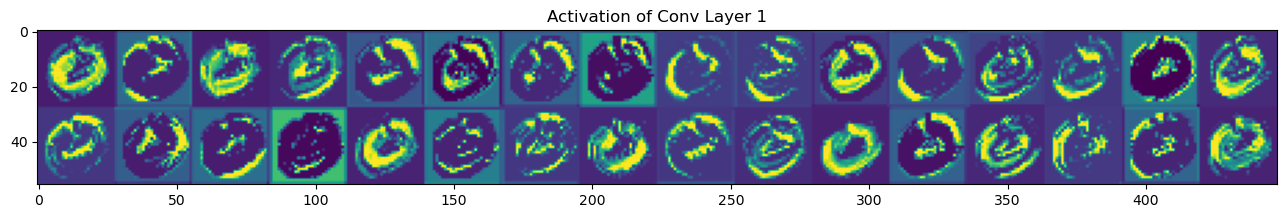

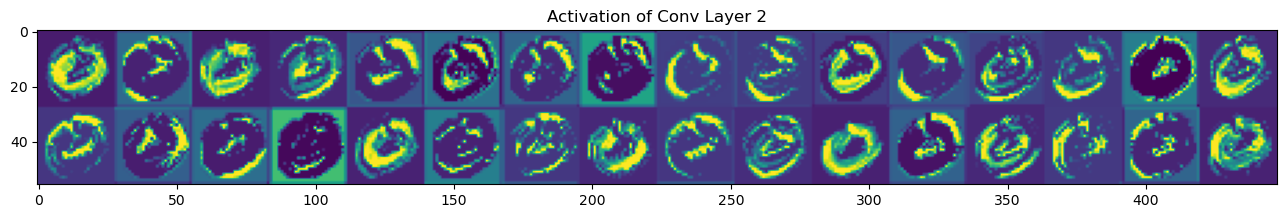

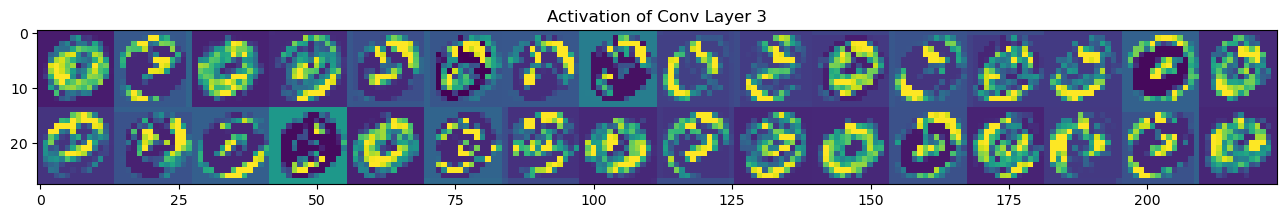

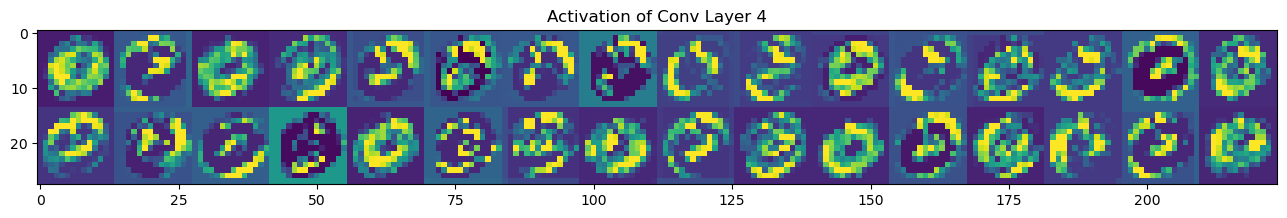

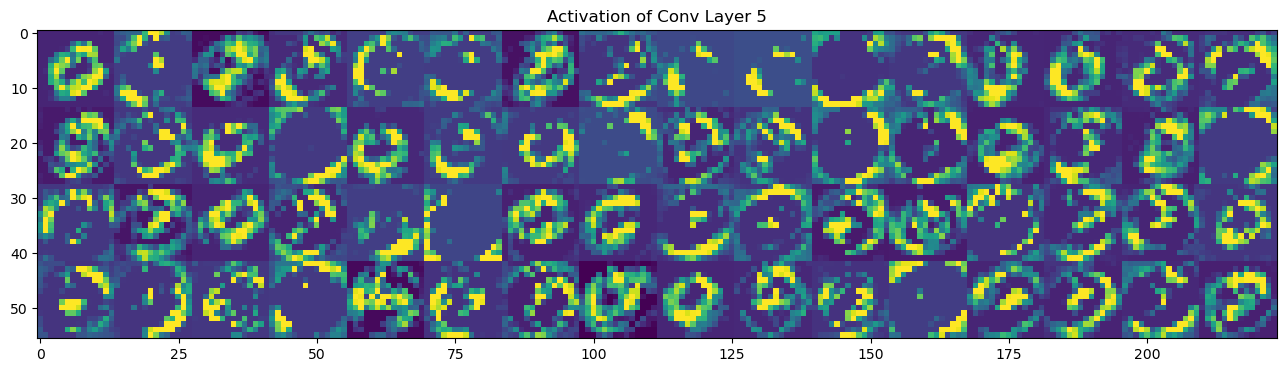

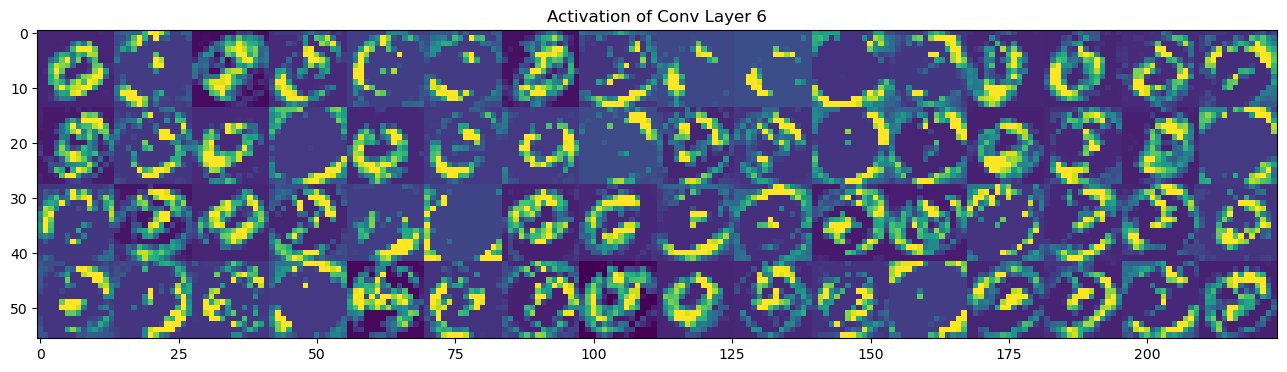

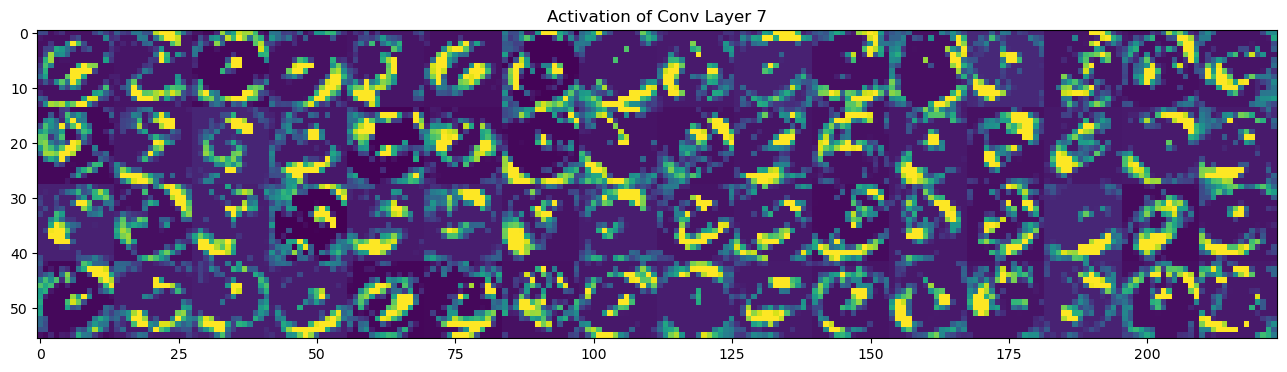

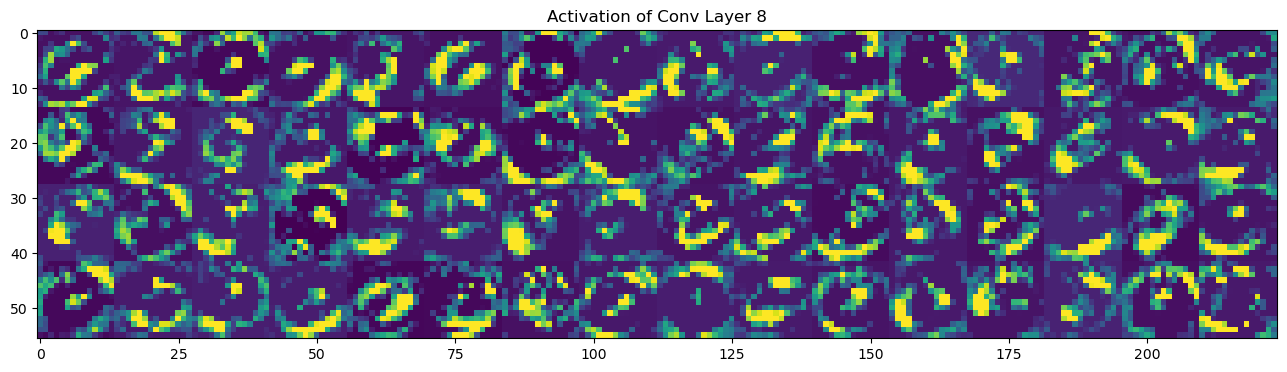

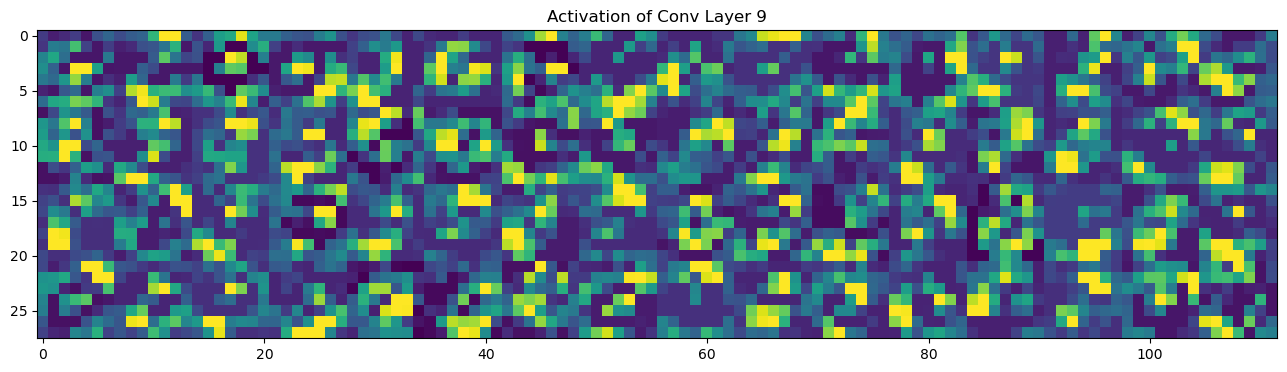

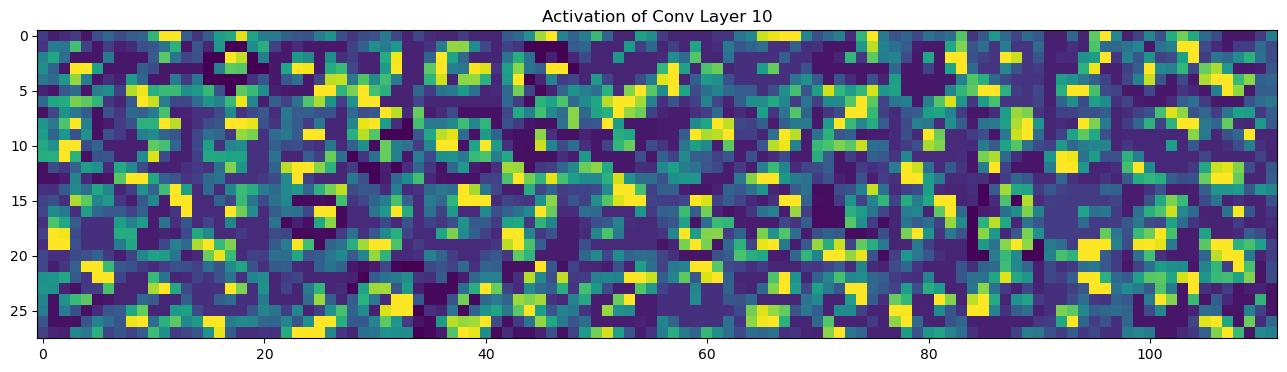

C:\Users\Isaac\anaconda3\envs\Work4\lib\site-packages\ipykernel_launcher.py:16: RuntimeWarning: invalid value encountered in true_divide
  


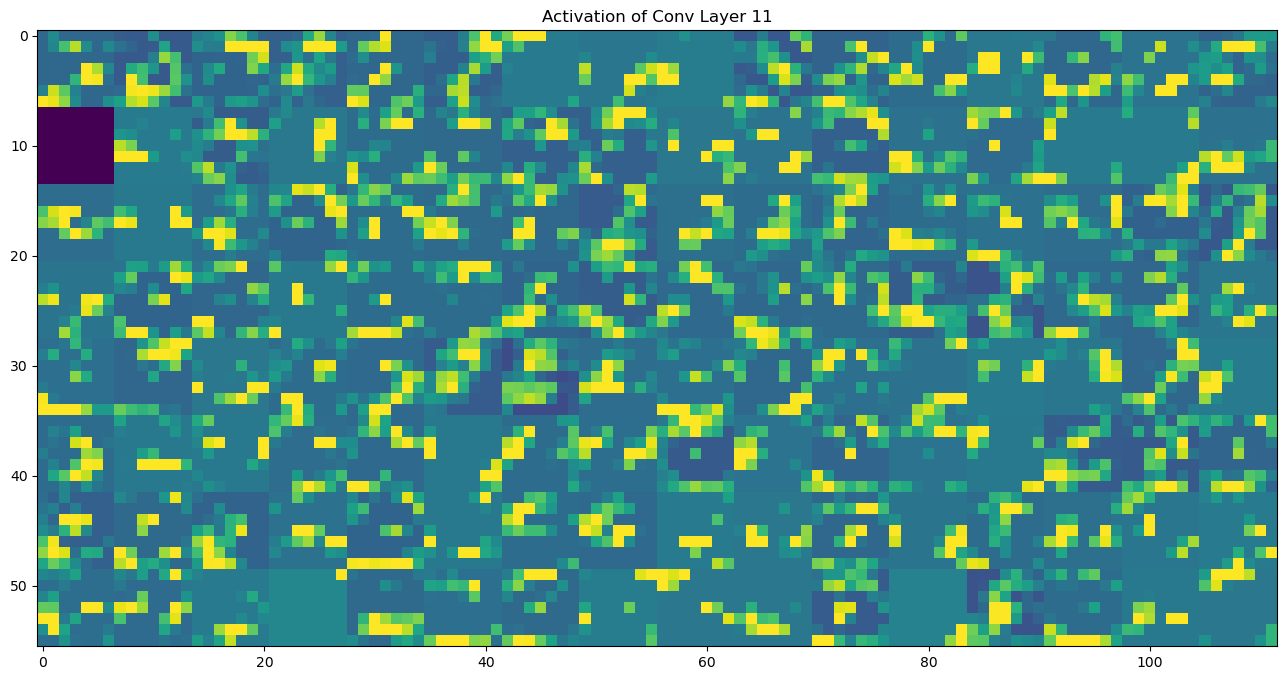

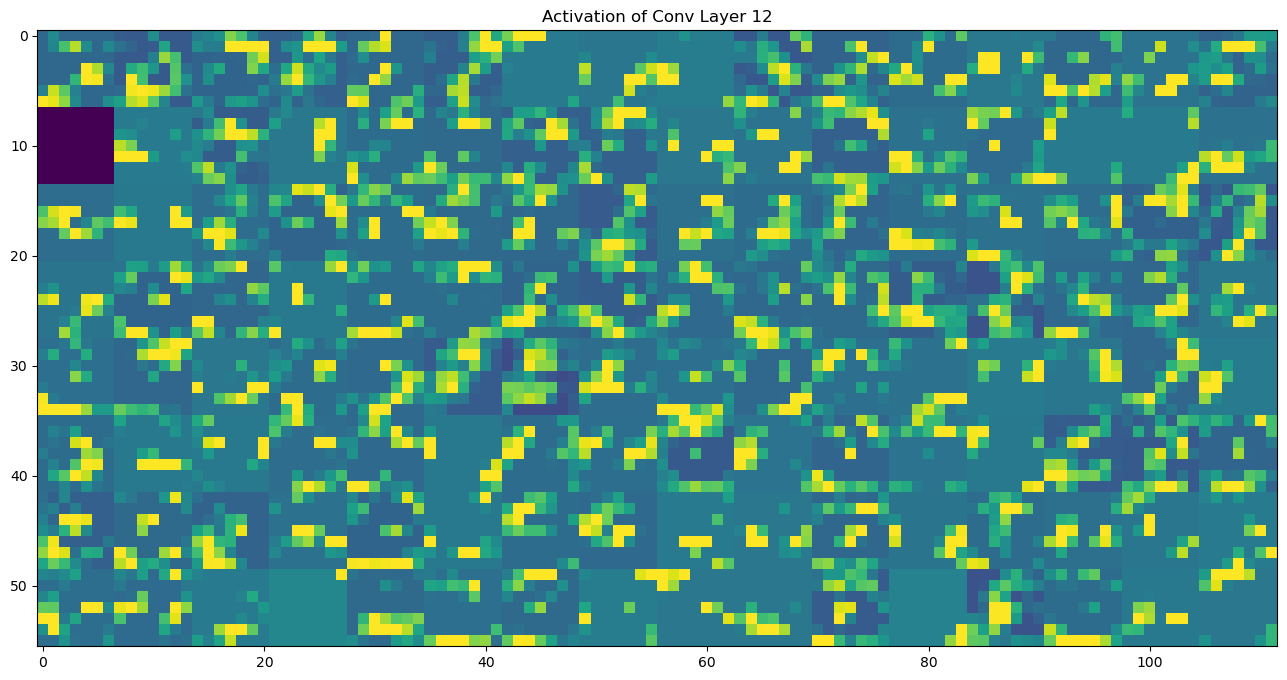

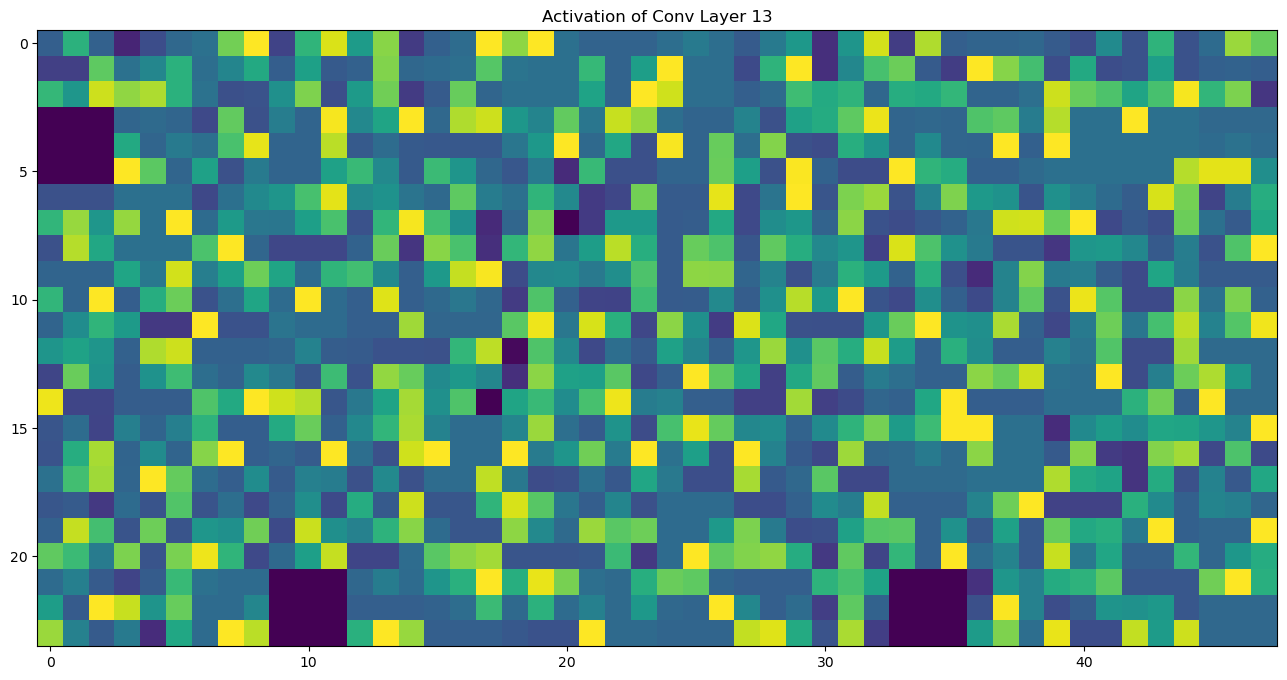

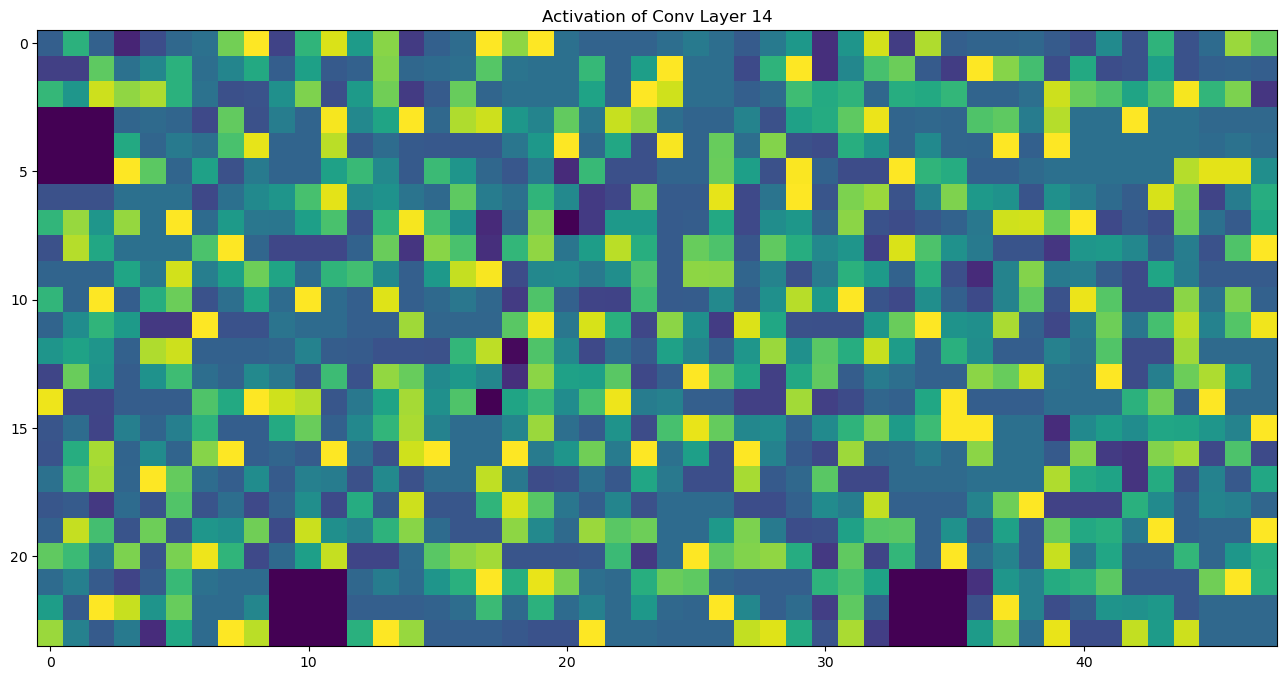

Skipping visualization for layer 15: Shape - (1, 1152)
Skipping visualization for layer 16: Shape - (1, 200)
Skipping visualization for layer 17: Shape - (1, 200)


In [13]:
visualize_layers(eval_data[25:26]) 